In [3]:
from google.colab import files

uploaded = files.upload()

Saving fraudTrain.csv.zip to fraudTrain.csv.zip


In [61]:
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 한글 깨짐 방지(Colab)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [62]:
df = pd.read_csv("fraudTrain.csv.zip")

In [63]:
# 1. 결측치 확인
df.isnull().sum()

# 2. 중복 확인
df.duplicated().sum()

# 3. 자료형 확인
df.info()

# 4. 날짜형 변환
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [ ]:
df.head()

In [ ]:
df.info()  #데이터 타입 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   Unnamed: 0             1296675 non-null  int64         
 1   trans_date_trans_time  1296675 non-null  datetime64[ns]
 2   cc_num                 1296675 non-null  int64         
 3   merchant               1296675 non-null  object        
 4   category               1296675 non-null  object        
 5   amt                    1296675 non-null  float64       
 6   first                  1296675 non-null  object        
 7   last                   1296675 non-null  object        
 8   gender                 1296675 non-null  object        
 9   street                 1296675 non-null  object        
 10  city                   1296675 non-null  object        
 11  state                  1296675 non-null  object        
 12  zip                    12966

In [ ]:
print(df.columns) #컬럼명 확인

In [ ]:
num_cols = [
    'amt',
    'city_pop',
    'lat',
    'long',
    'merch_lat',
    'merch_long'
]

df[num_cols].describe().T.round(2) ###수치형 변수 기술통계

,count,mean,std,min,25%,50%,75%,max
amt,1296675.0,70.35,160.32,1.00,9.65,47.52,83.14,28948.90
city_pop,1296675.0,88824.44,301956.36,23.00,743.00,2456.00,20328.00,2906700.00
lat,1296675.0,38.54,5.08,20.03,34.62,39.35,41.94,66.69
long,1296675.0,-90.23,13.76,-165.67,-96.80,-87.48,-80.16,-67.95
merch_lat,1296675.0,38.54,5.11,19.03,34.73,39.37,41.96,67.51
merch_long,1296675.0,-90.23,13.77,-166.67,-96.90,-87.44,-80.24,-66.95


In [ ]:
cat_cols = [
    'merchant',
    'category',
    'gender',
    'city',
    'state',
    'job'
]

df[cat_cols].describe().T    ###범주형 기술통계

,count,unique,top,freq
merchant,1296675,693,fraud_Kilback LLC,4403
category,1296675,14,gas_transport,131659
gender,1296675,2,F,709863
city,1296675,894,Birmingham,5617
state,1296675,51,TX,94876
job,1296675,494,Film/video editor,9779


In [ ]:
df.dtypes

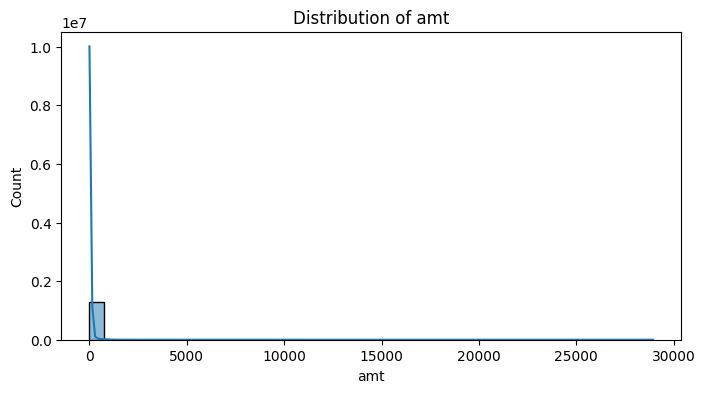

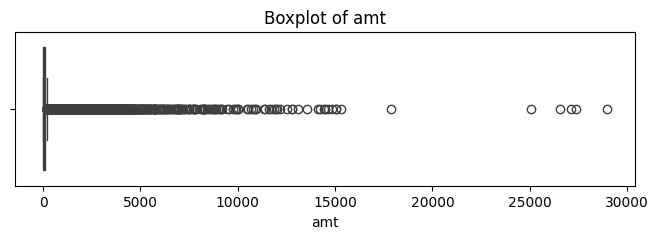

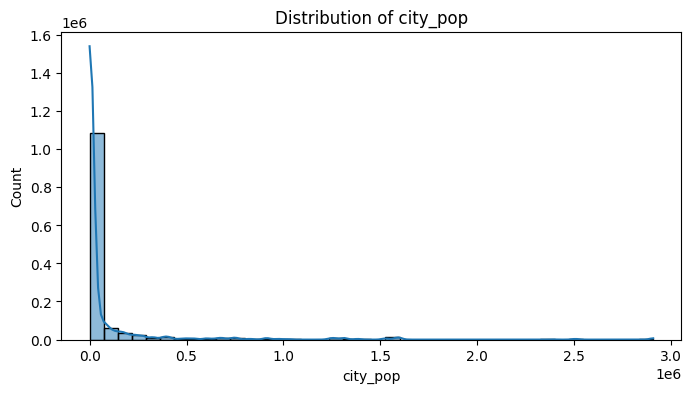

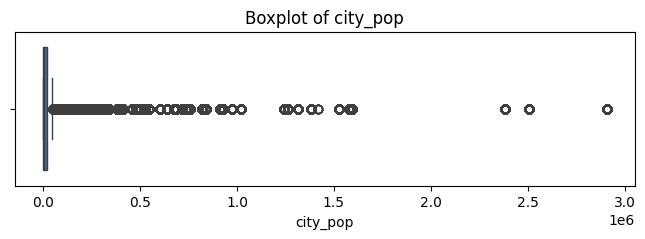

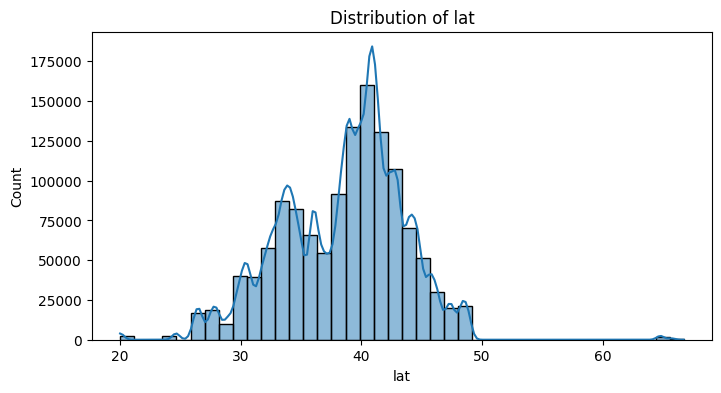

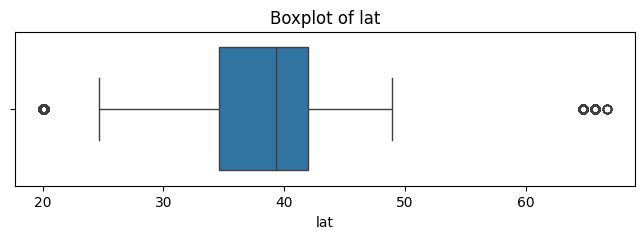

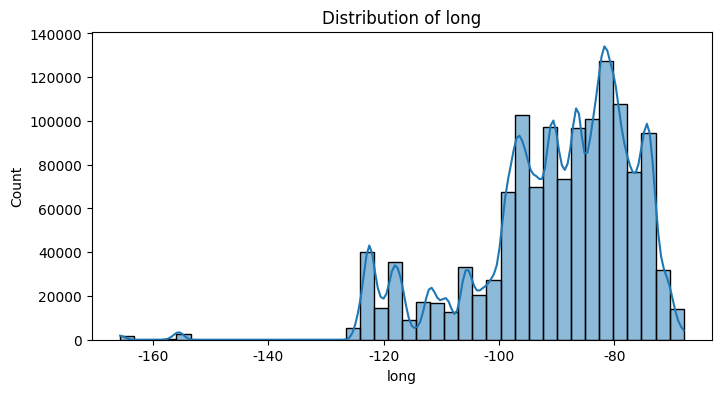

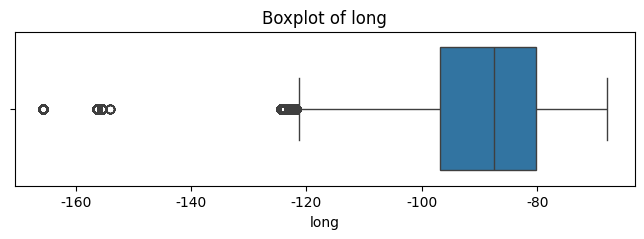

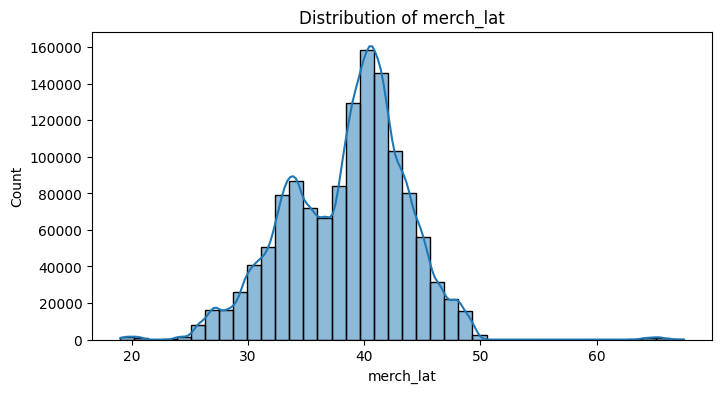

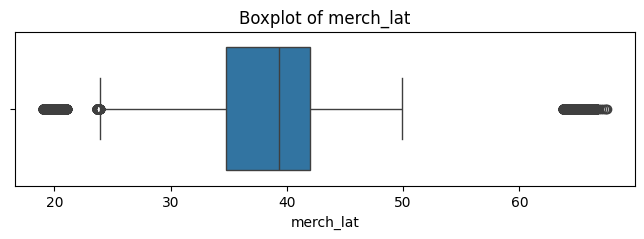

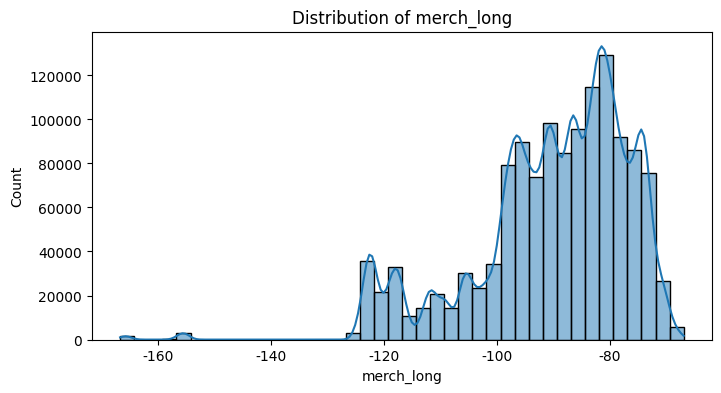

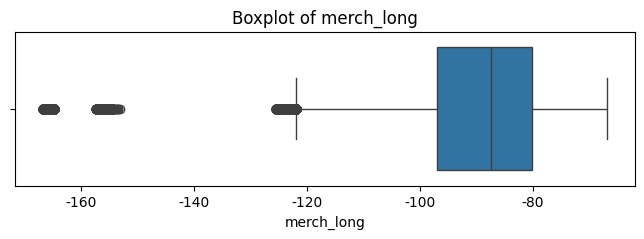

In [ ]:
######수치형변수 시각화코드
num_cols = [
    'amt',
    'city_pop',
    'lat',
    'long',
    'merch_lat',
    'merch_long'
]

for col in num_cols:

    plt.figure(figsize=(8,4))
    sns.histplot(df[col], bins=40, kde=True)

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

    plt.show()

    plt.figure(figsize=(8,2))
    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')

    plt.show()

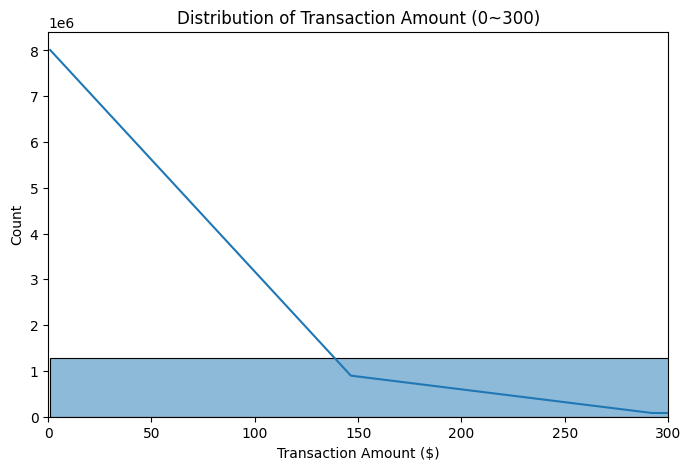

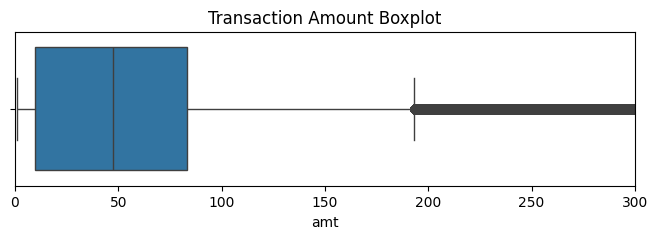

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['amt'], bins=50, kde=True)

plt.xlim(0,300)

plt.title('Distribution of Transaction Amount (0~300)')
plt.xlabel('Transaction Amount ($)')
plt.ylabel('Count')

plt.show()

plt.figure(figsize=(8,2))

sns.boxplot(x=df['amt'])

plt.xlim(0,300)

plt.title('Transaction Amount Boxplot')

plt.show()

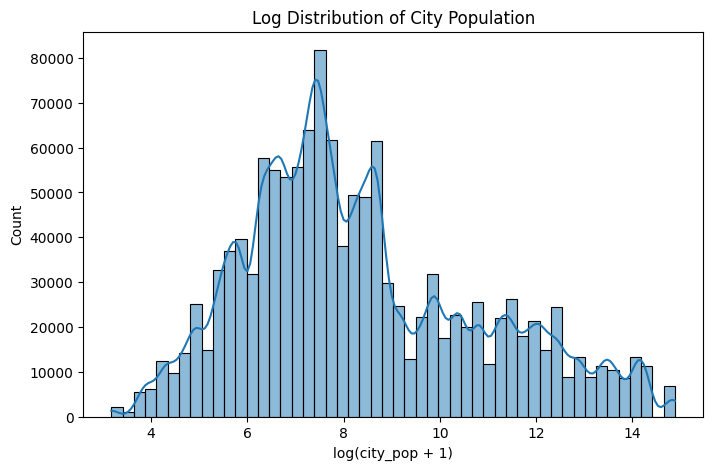

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(np.log1p(df['city_pop']), bins=50, kde=True)

plt.title('Log Distribution of City Population')
plt.xlabel('log(city_pop + 1)')

plt.show()

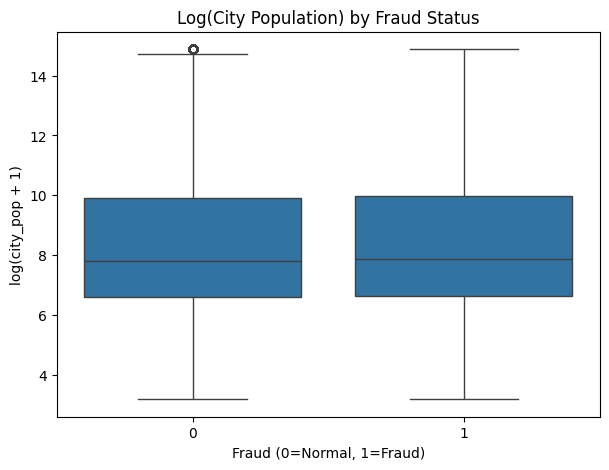

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='is_fraud',
    y=np.log1p(df['city_pop'])
)

plt.title('Log(City Population) by Fraud Status')
plt.xlabel('Fraud (0=Normal, 1=Fraud)')
plt.ylabel('log(city_pop + 1)')

plt.show()

In [ ]:
df[['cc_num','move_distance_km']].head()

,cc_num,move_distance_km
0,60416207185,NaN
1,60416207185,224.769219
2,60416207185,105.220439
3,60416207185,88.152283
4,60416207185,132.876773


In [ ]:
#!pip install haversine

In [64]:
from math import radians, sin, cos, sqrt, atan2

def haversine_distance(lat1, lon1, lat2, lon2):

    R = 6371.0

    lat1, lon1, lat2, lon2 = map(
        radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))

    return R * c

In [82]:
# 온라인 거래 제거
offline_df = df[~df['category'].isin(['shopping_net', 'misc_net','grocery_net'])].copy()

print(offline_df.shape)
offline_df['category'].value_counts()

offline_df = offline_df.sort_values(
    ['cc_num', 'trans_date_trans_time']
)

offline_df['prev_lat'] = (
    offline_df.groupby('cc_num')['merch_lat']
    .shift(1)
)

offline_df['prev_long'] = (
    offline_df.groupby('cc_num')['merch_long']
    .shift(1)
)

offline_df['move_distance_km'] = offline_df.apply(
    lambda x: haversine_distance(
        x['prev_lat'],
        x['prev_long'],
        x['merch_lat'],
        x['merch_long']
    )
    if pd.notnull(x['prev_lat']) else np.nan,
    axis=1
)

offline_df['time_diff_sec'] = (
    offline_df.groupby('cc_num')['trans_date_trans_time']
    .diff()
    .dt.total_seconds()
)
offline_df['speed_kmh'] = np.where(
    offline_df['time_diff_sec'] > 0,
    offline_df['move_distance_km'] / (offline_df['time_diff_sec'] / 3600),
    np.nan
)


(1090393, 25)


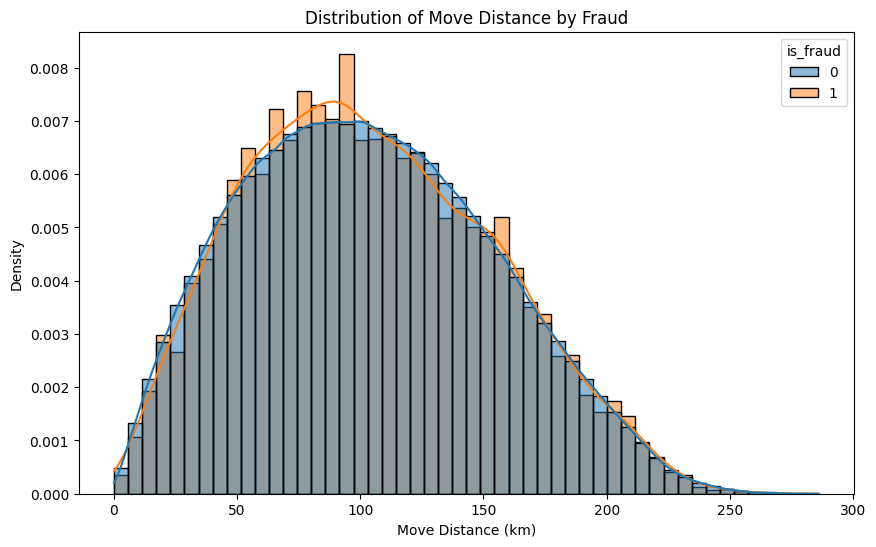

In [ ]:
####파생변수 시각화 코드

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='move_distance_km',
    hue='is_fraud',
    bins=50,
    kde=True,
    stat='density',
    common_norm=False,
    alpha=0.5
)

plt.xlabel('Move Distance (km)')
plt.title('Distribution of Move Distance by Fraud')

plt.show()

In [66]:
import numpy as np
import pandas as pd

# 날짜형 변환
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# 정렬
df = df.sort_values(['cc_num', 'trans_date_trans_time']).reset_index(drop=True)

# 결과 저장
df['count_30min'] = 0

# 카드별 계산
for cc_num, idx in df.groupby('cc_num').groups.items():

    times = df.loc[idx, 'trans_date_trans_time'].values.astype('datetime64[s]')

    left = np.searchsorted(
        times,
        times - np.timedelta64(30, 'm')
    )

    right = np.arange(len(times))

    df.loc[idx, 'count_30min'] = right - left + 1



In [67]:
df['count_30min'].value_counts().sort_index().head(20)

,count
count_30min,
1,1182226
2,105948
3,7820
4,630
5,50
6,1


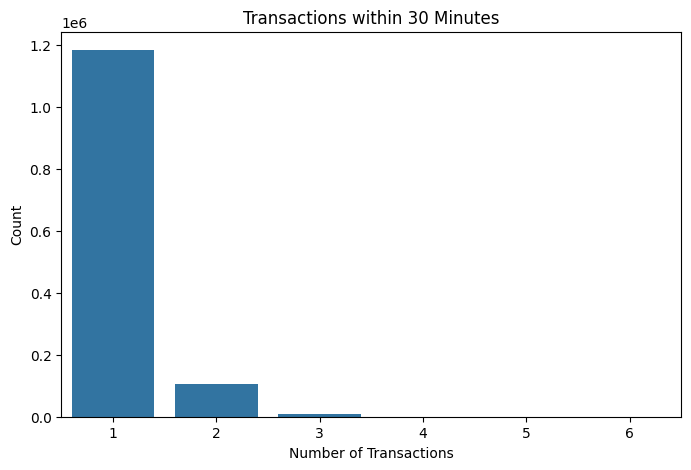

In [ ]:
plt.figure(figsize=(8,5))

order = sorted(df['count_30min'].unique())

sns.countplot(
    data=df,
    x='count_30min',
    order=order
)

plt.title('Transactions within 30 Minutes')
plt.xlabel('Number of Transactions')
plt.ylabel('Count')

plt.show()

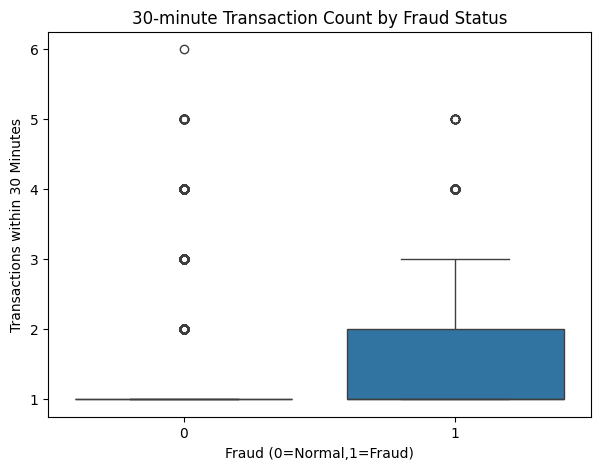

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='is_fraud',
    y='count_30min'
)

plt.title('30-minute Transaction Count by Fraud Status')
plt.xlabel('Fraud (0=Normal,1=Fraud)')
plt.ylabel('Transactions within 30 Minutes')

plt.show()

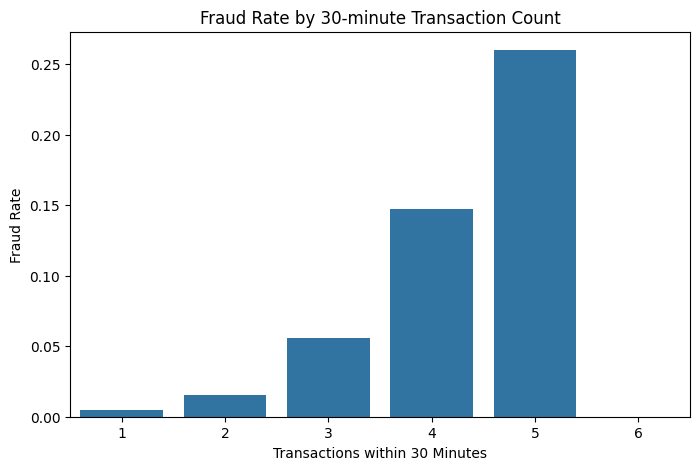

In [14]:
fraud_rate = (
    df.groupby('count_30min')['is_fraud']
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=fraud_rate,
    x='count_30min',
    y='is_fraud'
)

plt.title("Fraud Rate by 30-minute Transaction Count")
plt.xlabel("Transactions within 30 Minutes")
plt.ylabel("Fraud Rate")

plt.show()

In [68]:
#거래건수+사기율
summary = (
    df.groupby('count_30min')
      .agg(
          transaction_count=('is_fraud', 'count'),
          fraud_count=('is_fraud', 'sum'),
          fraud_rate=('is_fraud', 'mean')
      )
)

print(summary)

             transaction_count  fraud_count  fraud_rate
count_30min                                            
1                      1182226         5351    0.004526
2                       105948         1610    0.015196
3                         7820          439    0.056138
4                          630           93    0.147619
5                           50           13    0.260000
6                            1            0    0.000000


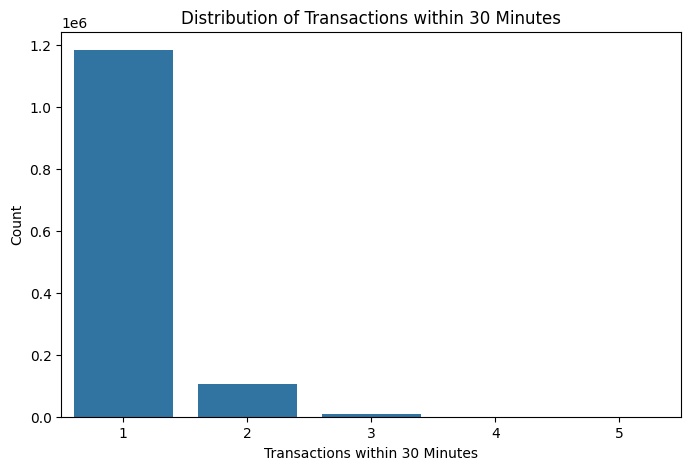

In [ ]:
##거래횟수
plt.figure(figsize=(8,5))

sns.countplot(
    data=df[df['count_30min'] <= 5],
    x='count_30min'
)

plt.title('Distribution of Transactions within 30 Minutes')
plt.xlabel('Transactions within 30 Minutes')
plt.ylabel('Count')

plt.show()

In [ ]:
df['count_30min'].value_counts().sort_index()

,count
count_30min,
1,1182226
2,105948
3,7820
4,630
5,50
6,1


In [69]:
df = df.sort_values(['cc_num','trans_date_trans_time'])

df['time_diff_sec'] = (
    df.groupby('cc_num')['trans_date_trans_time']
      .diff()
      .dt.total_seconds()
)


In [ ]:
print(df['trans_date_trans_time'].dtype)

datetime64[ns]


In [ ]:
df.groupby('is_fraud')['time_diff_sec'].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1288261.0,32549.396663,47449.270430,0.0,6064.0,16623.0,40262.0,1341471.0
1,7431.0,21323.662630,36436.695488,1.0,1473.0,4908.0,28974.5,865077.0


In [ ]:
df['time_diff_sec'].describe()

,time_diff_sec
count,1.295692e+06
mean,3.248502e+04
std,4.740098e+04
min,0.000000e+00
25%,6.013000e+03
50%,1.656000e+04
75%,4.022300e+04
max,1.341471e+06


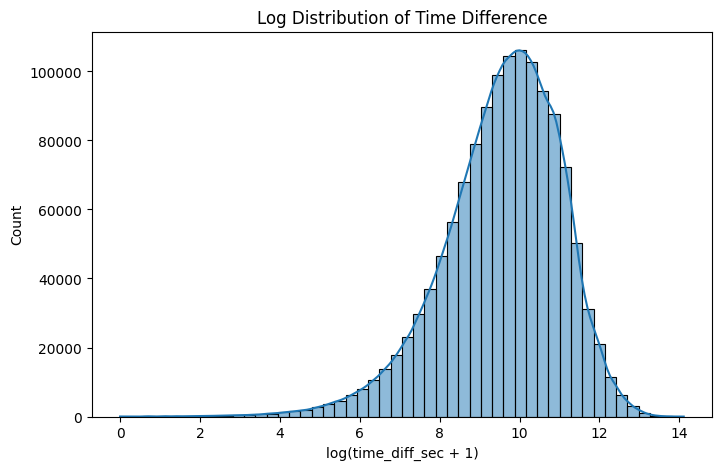

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    np.log1p(df['time_diff_sec'].dropna()),
    bins=50,
    kde=True
)

plt.title('Log Distribution of Time Difference')
plt.xlabel('log(time_diff_sec + 1)')

plt.show()

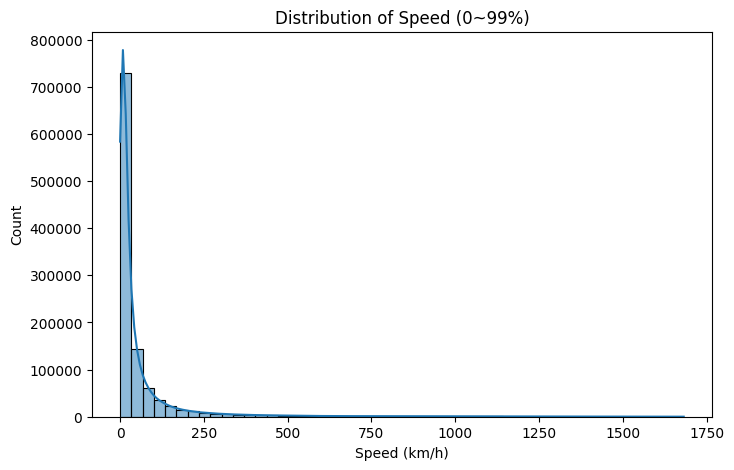

In [70]:
##이동속도
import matplotlib.pyplot as plt
import seaborn as sns

speed = offline_df['speed_kmh'].replace([np.inf, -np.inf], np.nan).dropna()

plt.figure(figsize=(8,5))

sns.histplot(
    speed[speed <= speed.quantile(0.99)],
    bins=50,
    kde=True
)

plt.title('Distribution of Speed (0~99%)')
plt.xlabel('Speed (km/h)')
plt.ylabel('Count')

plt.show()

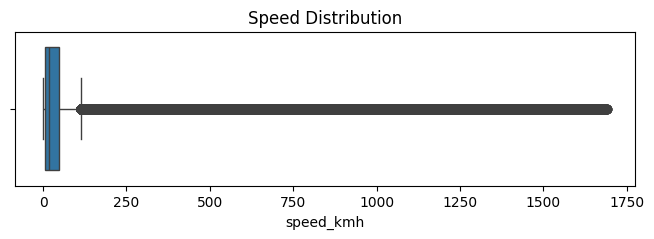

In [ ]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=speed[speed <= speed.quantile(0.99)]
)

plt.title("Speed Distribution")

plt.show()

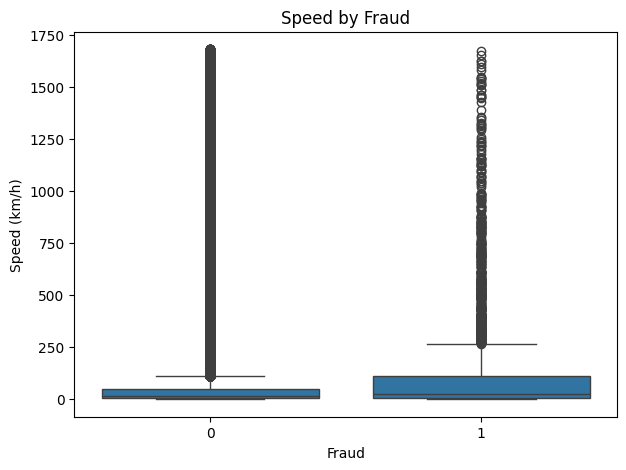

In [71]:
plot_df = offline_df.copy()

plot_df['speed_kmh'] = plot_df['speed_kmh'].replace([np.inf, -np.inf], np.nan)

plot_df = plot_df[
    plot_df['speed_kmh'] <= plot_df['speed_kmh'].quantile(0.99)
]

plt.figure(figsize=(7,5))

sns.boxplot(
    data=plot_df,
    x='is_fraud',
    y='speed_kmh'
)

plt.title("Speed by Fraud")
plt.xlabel("Fraud")
plt.ylabel("Speed (km/h)")

plt.show()

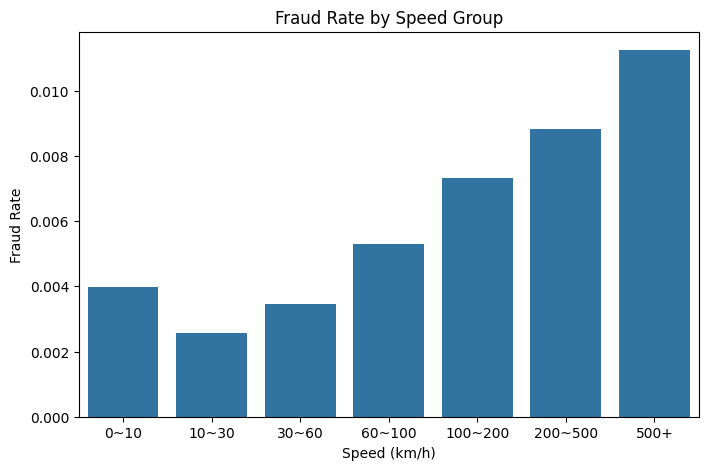

In [72]:
speed_df = offline_df.copy()

speed_df = speed_df.replace([np.inf, -np.inf], np.nan)
speed_df = speed_df.dropna(subset=['speed_kmh'])

bins = [0, 10, 30, 60, 100, 200, 500, speed_df['speed_kmh'].max()]
labels = ['0~10', '10~30', '30~60', '60~100', '100~200', '200~500', '500+']

speed_df['speed_group'] = pd.cut(
    speed_df['speed_kmh'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

fraud_rate = (
    speed_df.groupby('speed_group', observed=False)['is_fraud']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=fraud_rate,
    x='speed_group',
    y='is_fraud'
)

plt.title("Fraud Rate by Speed Group")
plt.xlabel("Speed (km/h)")
plt.ylabel("Fraud Rate")

plt.show()

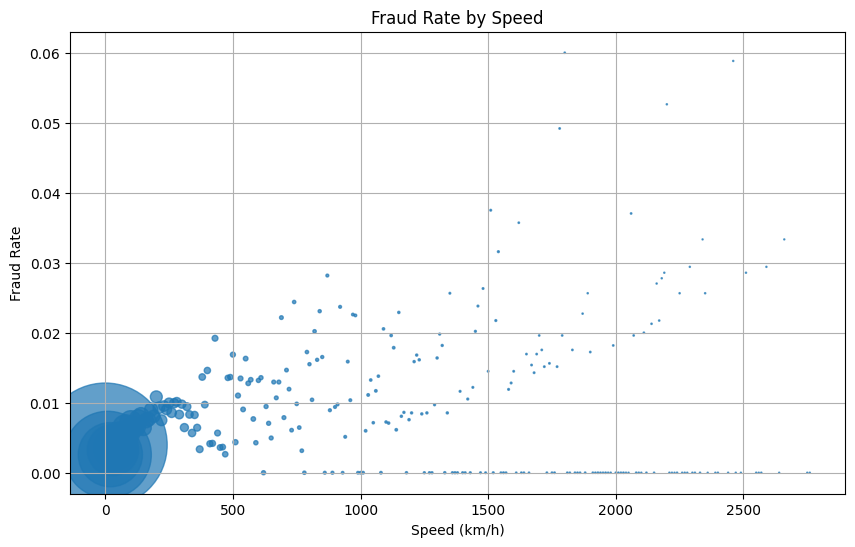

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

speed_df = offline_df.copy()

# inf 제거
speed_df = speed_df.replace([np.inf, -np.inf], np.nan)
speed_df = speed_df.dropna(subset=['speed_kmh'])

# 이동속도를 10km/h 단위로 구간화
speed_df['speed_bin'] = (speed_df['speed_kmh'] // 10) * 10

fraud_rate = (
    speed_df
    .groupby('speed_bin')
    .agg(
        fraud_rate=('is_fraud', 'mean'),
        transaction_count=('is_fraud', 'count')
    )
    .reset_index()
)

# 거래가 너무 적은 구간 제거(예: 30건 미만)
fraud_rate = fraud_rate[fraud_rate['transaction_count'] >= 30]

plt.figure(figsize=(10,6))

plt.scatter(
    fraud_rate['speed_bin'],
    fraud_rate['fraud_rate'],
    s=fraud_rate['transaction_count']/50,   # 거래량에 따라 점 크기
    alpha=0.7
)

plt.xlabel("Speed (km/h)")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Speed")

plt.grid(True)

plt.show()

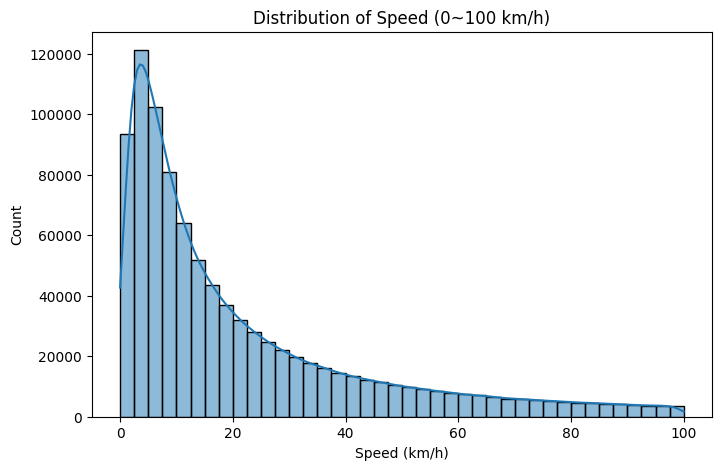

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

speed_df = offline_df.copy()

# inf 제거
speed_df['speed_kmh'] = speed_df['speed_kmh'].replace([np.inf, -np.inf], np.nan)

# 0~100km/h만 선택
speed_plot = speed_df[
    (speed_df['speed_kmh'] >= 0) &
    (speed_df['speed_kmh'] <= 100)
]

plt.figure(figsize=(8,5))

sns.histplot(
    speed_plot['speed_kmh'],
    bins=40,
    kde=True
)

plt.xlabel("Speed (km/h)")
plt.ylabel("Count")
plt.title("Distribution of Speed (0~100 km/h)")

plt.show()

In [35]:
plot_df = speed_plot.copy()

# 5km/h 단위 구간
plot_df['speed_bin'] = (plot_df['speed_kmh'] // 5) * 5

fraud_rate = (
    plot_df
    .groupby('speed_bin')
    .agg(
        fraud_rate=('is_fraud','mean'),
        transaction_count=('is_fraud','count')
    )
    .reset_index()
)

# 거래건수가 너무 적은 구간 제거
fraud_rate = fraud_rate[
    fraud_rate['transaction_count'] >= 30
]

plt.figure(figsize=(9,5))

plt.scatter(
    fraud_rate['speed_bin'],
    fraud_rate['fraud_rate'],
    s=fraud_rate['transaction_count']/100,
    alpha=0.8
)

plt.xlabel("Speed (km/h)")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Speed (0~100 km/h)")

plt.grid(True)

plt.show()

NameError: name 'speed_plot' is not defined

   speed_group  transaction_count  fraud_count  fraud_rate
0     ≤10 km/h             397873         1578    0.003966
1  10~100 km/h             534623         1727    0.003230
2    >100 km/h             156898         1364    0.008694


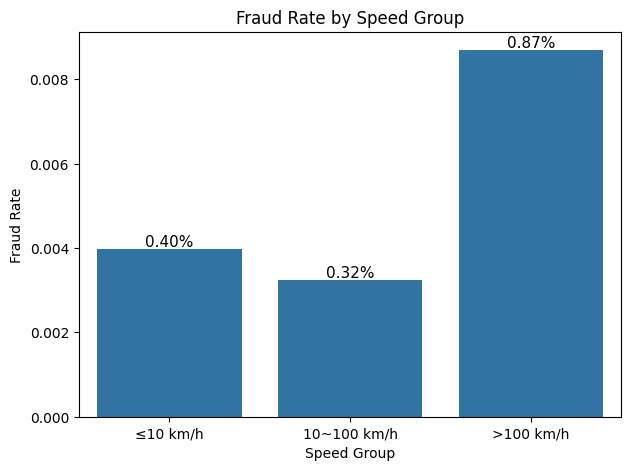

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = offline_df.copy()

# inf 제거
plot_df = plot_df.replace([np.inf, -np.inf], np.nan)
plot_df = plot_df.dropna(subset=['speed_kmh'])

# 속도 구간 생성
plot_df['speed_group'] = pd.cut(
    plot_df['speed_kmh'],
    bins=[0, 10, 100, np.inf],
    labels=['≤10 km/h', '10~100 km/h', '>100 km/h'],
    include_lowest=True
)

# 사기율 계산
result = (
    plot_df.groupby('speed_group', observed=False)
    .agg(
        transaction_count=('is_fraud','count'),
        fraud_count=('is_fraud','sum'),
        fraud_rate=('is_fraud','mean')
    )
    .reset_index()
)

print(result)

# 시각화
plt.figure(figsize=(7,5))

sns.barplot(
    data=result,
    x='speed_group',
    y='fraud_rate'
)

# 막대 위에 사기율 표시
for i, rate in enumerate(result['fraud_rate']):
    plt.text(i, rate, f"{rate:.2%}", ha='center', va='bottom', fontsize=11)

plt.xlabel("Speed Group")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Speed Group")

plt.show()

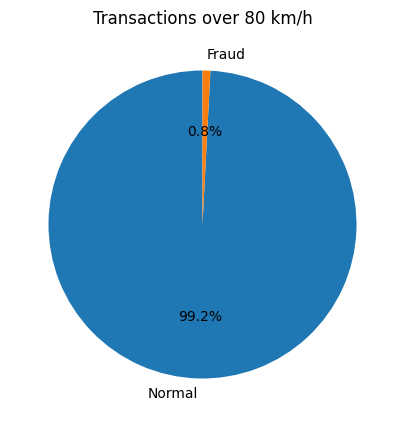

In [ ]:
speed80 = offline_df[
    (offline_df['speed_kmh'] >= 80) &
    (offline_df['speed_kmh'] != np.inf)
].copy()

count_df = (
    speed80['is_fraud']
    .value_counts()
    .rename(index={0:'Normal', 1:'Fraud'})
)

plt.figure(figsize=(5,5))

plt.pie(
    count_df,
    labels=count_df.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Transactions over 80 km/h')

plt.show()

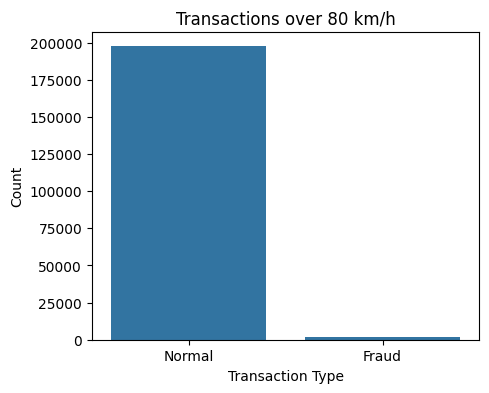

In [ ]:
count_df = (
    speed80['is_fraud']
    .value_counts()
    .rename(index={0:'Normal',1:'Fraud'})
)

plt.figure(figsize=(5,4))

sns.barplot(
    x=count_df.index,
    y=count_df.values
)

plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.title("Transactions over 80 km/h")

plt.show()

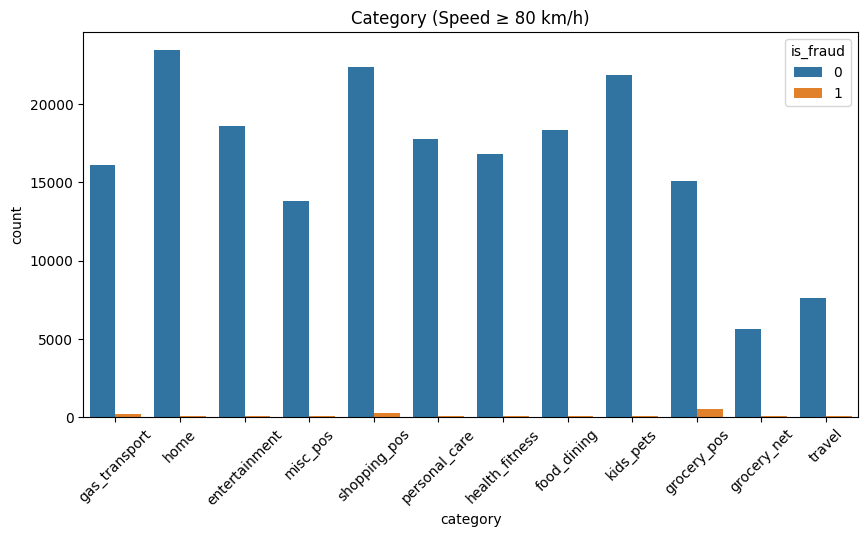

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=speed80,
    x='category',
    hue='is_fraud'
)

plt.xticks(rotation=45)

plt.title("Category (Speed ≥ 80 km/h)")

plt.show()

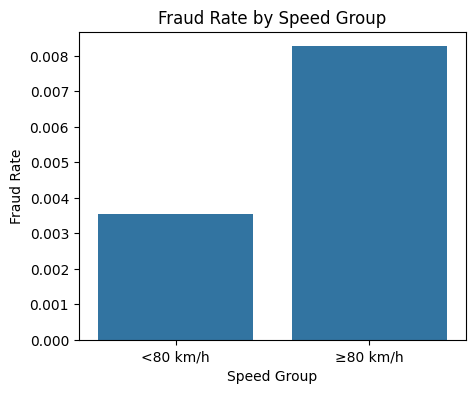

  speed_group  transaction_count  fraud_count  fraud_rate
0    <80 km/h             901288         3182    0.003531
1    ≥80 km/h             189105         1562    0.008260


In [75]:
compare = offline_df.copy()

compare['speed_group'] = np.where(
    compare['speed_kmh'] >= 80,
    '≥80 km/h',
    '<80 km/h'
)

result = (
    compare.groupby('speed_group')
    .agg(
        transaction_count=('is_fraud','count'),
        fraud_count=('is_fraud','sum'),
        fraud_rate=('is_fraud','mean')
    )
    .reset_index()
)

plt.figure(figsize=(5,4))

sns.barplot(
    data=result,
    x='speed_group',
    y='fraud_rate'
)

plt.ylabel("Fraud Rate")
plt.xlabel("Speed Group")
plt.title("Fraud Rate by Speed Group")

plt.show()

print(result)

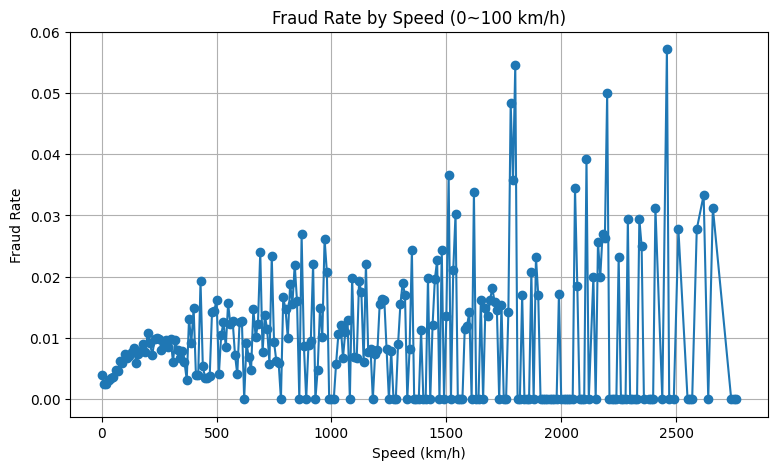

In [ ]:
plt.figure(figsize=(9,5))

plt.plot(
    fraud_rate['speed_bin'],
    fraud_rate['fraud_rate'],
    marker='o'
)

plt.xlabel("Speed (km/h)")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Speed (0~100 km/h)")

plt.grid(True)

plt.show()

In [ ]:
speed70 = speed_df[speed_df['speed_kmh'] >= 70]

print("거래건수 :", len(speed70))
print("사기건수 :", speed70['is_fraud'].sum())
print("사기율 :", speed70['is_fraud'].mean())

거래건수 : 221884
사기건수 : 1738
사기율 : 0.007832921706837807


In [ ]:
result = (
    speed_df.assign(
        speed_group=np.where(
            speed_df['speed_kmh'] >= 70,
            '70km/h 이상',
            '70km/h 미만'
        )
    )
    .groupby('speed_group')
    .agg(
        transaction_count=('is_fraud','count'),
        fraud_count=('is_fraud','sum'),
        fraud_rate=('is_fraud','mean')
    )
)

print(result)

             transaction_count  fraud_count  fraud_rate
speed_group                                            
70km/h 미만               912962         3065    0.003357
70km/h 이상               221884         1738    0.007833


Shapiro-Wilk statistic : 0.0197
p-value : 0.0000000000
정규성을 만족하지 않는다.


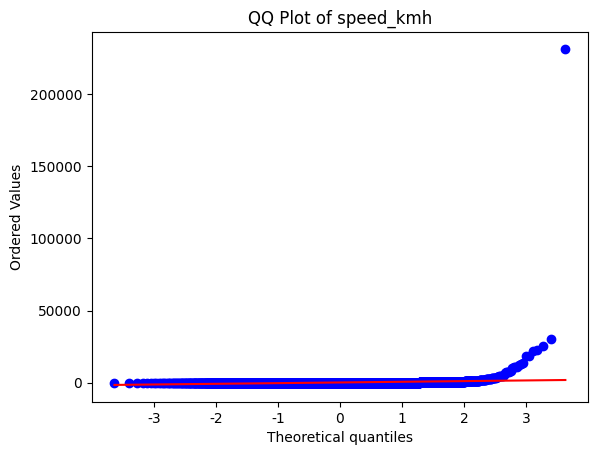

In [18]:
############7월30일
from scipy.stats import shapiro
import numpy as np

# inf 제거
speed = offline_df['speed_kmh'].replace([np.inf, -np.inf], np.nan).dropna()

# 표본 추출 (최대 5000개)
sample = speed.sample(5000, random_state=42)

stat, p = shapiro(sample)

print(f"Shapiro-Wilk statistic : {stat:.4f}")
print(f"p-value : {p:.10f}")

if p > 0.05:
    print("정규성을 만족한다.")
else:
    print("정규성을 만족하지 않는다.")


from scipy import stats
import matplotlib.pyplot as plt

stats.probplot(sample, dist="norm", plot=plt)

plt.title("QQ Plot of speed_kmh")
plt.show()

In [19]:
from scipy.stats import mannwhitneyu

normal = offline_df.loc[
    offline_df['is_fraud'] == 0,
    'speed_kmh'
].replace([np.inf,-np.inf], np.nan).dropna()

fraud = offline_df.loc[
    offline_df['is_fraud'] == 1,
    'speed_kmh'
].replace([np.inf,-np.inf], np.nan).dropna()

stat, p = mannwhitneyu(
    fraud,
    normal,
    alternative='greater'
)

print(f"U statistic : {stat:.0f}")
print(f"p-value : {p:.10f}")

if p < 0.05:
    print("귀무가설 기각")
    print("사기 거래의 이동속도가 정상 거래보다 유의하게 높다.")
else:
    print("귀무가설 채택")



U statistic : 2908540303
p-value : 0.0000000000
귀무가설 기각
사기 거래의 이동속도가 정상 거래보다 유의하게 높다.


In [41]:
import pandas as pd
from scipy.stats import chi2_contingency

# 교차표 생성
table = pd.crosstab(df['count_30min'], df['is_fraud'])

print(table)

# 카이제곱 검정
chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-square statistic : {chi2:.4f}")
print(f"Degrees of freedom : {dof}")
print(f"p-value : {p:.10f}")

if p < 0.05:
    print("귀무가설 기각")
    print("→ 30분 이내 연속결제 횟수와 이상거래 여부는 유의한 관련이 있다.")
else:
    print("귀무가설 채택")

is_fraud           0     1
count_30min               
1            1176875  5351
2             104338  1610
3               7381   439
4                537    93
5                 37    13
6                  1     0
Chi-square statistic : 8164.7128
Degrees of freedom : 5
p-value : 0.0000000000
귀무가설 기각
→ 30분 이내 연속결제 횟수와 이상거래 여부는 유의한 관련이 있다.


In [42]:
from scipy.stats import mannwhitneyu

# 정상거래
normal = df.loc[df['is_fraud'] == 0, 'count_30min']

# 이상거래
fraud = df.loc[df['is_fraud'] == 1, 'count_30min']

# Mann-Whitney U 검정
stat, p = mannwhitneyu(
    fraud,
    normal,
    alternative='greater'
)

print(f"U statistic : {stat:.4f}")
print(f"p-value : {p:.10f}")

if p < 0.05:
    print("귀무가설 기각")
    print("→ 이상거래의 30분 이내 연속결제 횟수가 정상거래보다 유의하게 많다.")
else:
    print("귀무가설 채택")

U statistic : 5828185695.0000
p-value : 0.0000000000
귀무가설 기각
→ 이상거래의 30분 이내 연속결제 횟수가 정상거래보다 유의하게 많다.


In [43]:
import statsmodels.api as sm

# 독립변수
X = df[['count_30min']]

# 절편 추가
X = sm.add_constant(X)

# 종속변수
y = df['is_fraud']

# 로지스틱 회귀
model1 = sm.Logit(y, X).fit()

print(model1.summary())

Optimization terminated successfully.
         Current function value: 0.034357
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:               is_fraud   No. Observations:              1296675
Model:                          Logit   Df Residuals:                  1296673
Method:                           MLE   Df Model:                            1
Date:                Thu, 30 Jul 2026   Pseudo R-squ.:                 0.03476
Time:                        14:09:46   Log-Likelihood:                -44550.
converged:                       True   LL-Null:                       -46154.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -6.6326      0.027   -245.773      0.000      -6.685      -6.580
count_30min     1.2388    

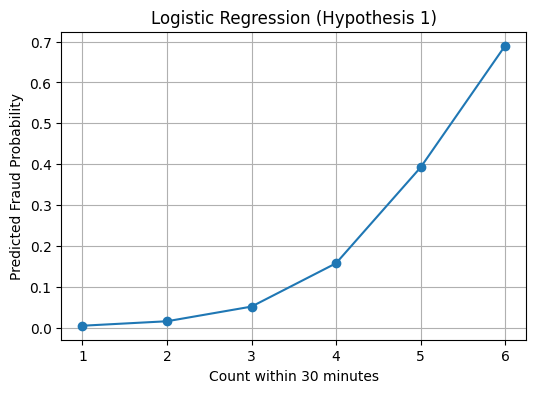

In [44]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(1, 7)

pred = model1.predict(
    sm.add_constant(pd.DataFrame({'count_30min': x}), has_constant='add')
)

plt.figure(figsize=(6,4))

plt.plot(x, pred, marker='o')

plt.xlabel("Count within 30 minutes")
plt.ylabel("Predicted Fraud Probability")
plt.title("Logistic Regression (Hypothesis 1)")

plt.grid(True)

plt.show()

In [45]:
speed_df = offline_df.copy()

# inf 제거
speed_df = speed_df.replace([np.inf,-np.inf], np.nan)
speed_df = speed_df.dropna(subset=['speed_kmh'])

X = speed_df[['speed_kmh']]
X = sm.add_constant(X)

y = speed_df['is_fraud']

model2 = sm.Logit(y, X).fit()

print(model2.summary())

Optimization terminated successfully.
         Current function value: 0.027638
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:               is_fraud   No. Observations:              1089394
Model:                          Logit   Df Residuals:                  1089392
Method:                           MLE   Df Model:                            1
Date:                Thu, 30 Jul 2026   Pseudo R-squ.:               0.0002386
Time:                        14:16:14   Log-Likelihood:                -30109.
converged:                       True   LL-Null:                       -30116.
Covariance Type:            nonrobust   LLR p-value:                 0.0001499
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.4497      0.015   -371.327      0.000      -5.478      -5.421
speed_kmh   5.931e-06    1.1e

(397873, 29)


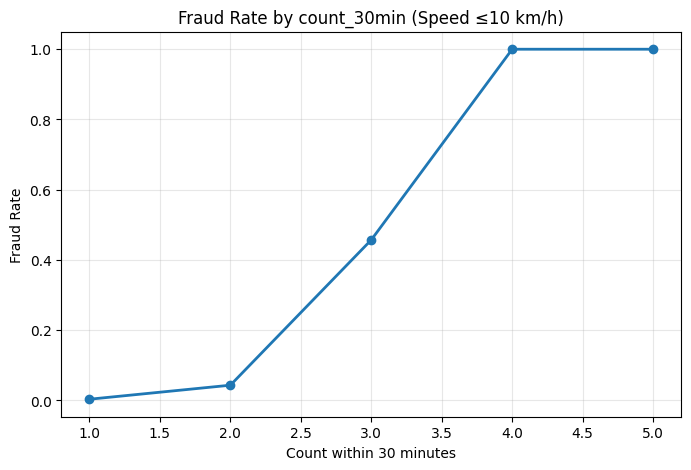

In [83]:
offline_df['count_30min'] = df.loc[offline_df.index, 'count_30min']


low_speed = offline_df[
    (offline_df['speed_kmh'] >= 0) &
    (offline_df['speed_kmh'] <= 10)
].copy()

print(low_speed.shape)

import matplotlib.pyplot as plt

summary = (
    low_speed.groupby('count_30min')
    .agg(
        transaction_count=('is_fraud','count'),
        fraud_count=('is_fraud','sum')
    )
)

summary['fraud_rate'] = (
    summary['fraud_count']
    / summary['transaction_count']
)

summary

plt.figure(figsize=(8,5))

plt.plot(
    summary.index,
    summary['fraud_rate'],
    marker='o',
    linewidth=2
)

plt.xlabel('Count within 30 minutes')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by count_30min (Speed ≤10 km/h)')
plt.grid(alpha=0.3)

plt.show()

In [85]:
from scipy.stats import mannwhitneyu

normal = low_speed.loc[
    low_speed['is_fraud']==0,
    'count_30min'
]

fraud = low_speed.loc[
    low_speed['is_fraud']==1,
    'count_30min'
]

u,p = mannwhitneyu(
    normal,
    fraud,
    alternative='two-sided'
)

print("U statistic :",u)
print("p-value :",p)

if p<0.05:
    print("귀무가설 기각")
else:
    print("귀무가설 채택")

U statistic : 275521635.0
p-value : 0.0
귀무가설 기각


In [86]:
summary = (
    low_speed.groupby('count_30min')
    .agg(
        거래건수=('is_fraud', 'count'),
        사기건수=('is_fraud', 'sum')
    )
)

summary['정상건수'] = summary['거래건수'] - summary['사기건수']
summary['사기율(%)'] = (
    summary['사기건수'] / summary['거래건수'] * 100
).round(2)

summary = summary[
    ['거래건수', '정상건수', '사기건수', '사기율(%)']
]

summary

,거래건수,정상건수,사기건수,사기율(%)
count_30min,,,,
1,393955,392579,1376,0.35
2,3845,3678,167,4.34
3,70,38,32,45.71
4,2,0,2,100.00
5,1,0,1,100.00


/tmp/ipykernel_789/946779271.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_low_speed.groupby('amt_group')


(1578, 29)


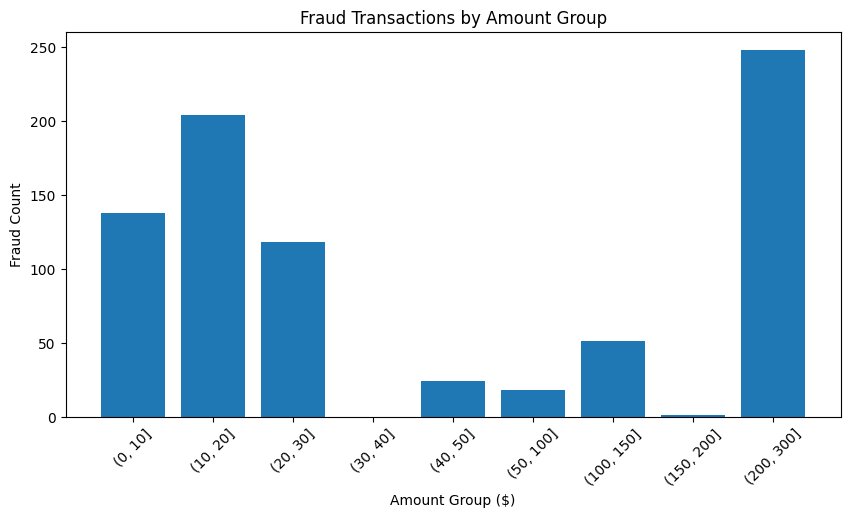

In [88]:
fraud_low_speed = offline_df[
    (offline_df['speed_kmh'] >= 0) &
    (offline_df['speed_kmh'] <= 10) &
    (offline_df['is_fraud'] == 1)
].copy()

print(fraud_low_speed.shape)
fraud_low_speed['amt'].describe().round(2)

bins = [0,10,20,30,40,50,100,150,200,300]

fraud_low_speed['amt_group'] = pd.cut(
    fraud_low_speed['amt'],
    bins=bins
)

summary = (
    fraud_low_speed.groupby('amt_group')
    .size()
    .reset_index(name='Fraud Count')
)

summary

plt.figure(figsize=(10,5))

plt.bar(
    summary['amt_group'].astype(str),
    summary['Fraud Count']
)

plt.xticks(rotation=45)
plt.xlabel('Amount Group ($)')
plt.ylabel('Fraud Count')
plt.title('Fraud Transactions by Amount Group')

plt.show()

In [89]:
summary = (
    fraud_low_speed
    .groupby('count_30min')
    .agg(
        거래수=('amt','count'),
        평균금액=('amt','mean'),
        중앙값=('amt','median'),
        최대금액=('amt','max')
    )
    .round(2)
)

summary

,거래수,평균금액,중앙값,최대금액
count_30min,,,,
1,1376,345.03,294.47,1371.81
2,167,480.48,363.09,1288.29
3,32,508.35,491.23,1157.97
4,2,725.95,725.95,972.28
5,1,49.76,49.76,49.76


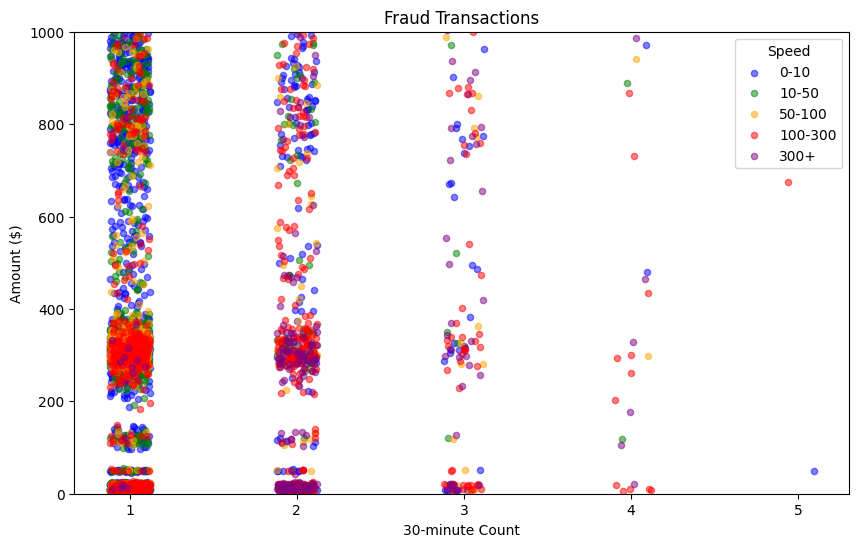

In [94]:
fraud_df = offline_df[offline_df['is_fraud'] == 1].copy()
import matplotlib.pyplot as plt


plot_df['speed_group'] = pd.cut(
    plot_df['speed_kmh'],
    bins=[0,10,50,100,300,100000],
    labels=[
        '0-10',
        '10-50',
        '50-100',
        '100-300',
        '300+'
    ]
)

colors={
    '0-10':'blue',
    '10-50':'green',
    '50-100':'orange',
    '100-300':'red',
    '300+':'purple'
}

plt.figure(figsize=(10,6))

for g,c in colors.items():

    temp=plot_df[
        plot_df['speed_group']==g
    ]

    plt.scatter(
        temp['count_30min']+np.random.uniform(-0.12,0.12,len(temp)),
        temp['amt'],
        color=c,
        alpha=0.5,
        label=g,
        s=20
    )

plt.legend(title="Speed")
plt.ylim(0,1000)

plt.xlabel("30-minute Count")
plt.ylabel("Amount ($)")
plt.title("Fraud Transactions")

plt.show()

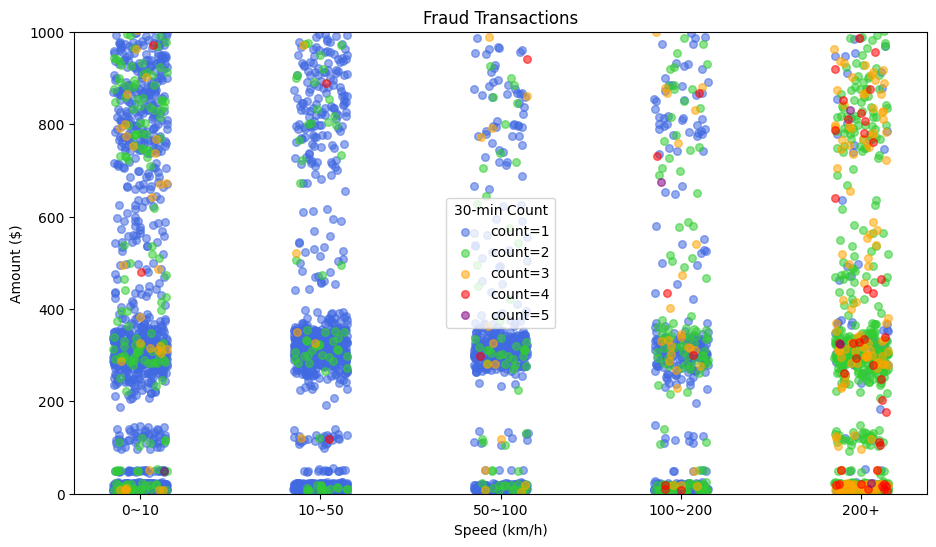

In [96]:
import numpy as np
import matplotlib.pyplot as plt

plot_df = offline_df[
    (offline_df['is_fraud'] == 1) &
    (offline_df['speed_kmh'] >= 0)
].copy()

# 속도 구간 생성
plot_df['speed_group'] = pd.cut(
    plot_df['speed_kmh'],
    bins=[0,10,50,100,200,np.inf],
    labels=['0~10','10~50','50~100','100~200','200+'],
    include_lowest=True
)

# x축 숫자로 변환
x_map = {
    '0~10':1,
    '10~50':2,
    '50~100':3,
    '100~200':4,
    '200+':5
}

plot_df['x'] = plot_df['speed_group'].map(x_map).astype(float)

# Jitter
plot_df['x_jitter'] = plot_df['x'] + np.random.uniform(-0.15,0.15,len(plot_df))

# 색상
color_map={
    1:'royalblue',
    2:'limegreen',
    3:'orange',
    4:'red',
    5:'purple'
}

plt.figure(figsize=(11,6))

for c,color in color_map.items():

    temp = plot_df[
        plot_df['count_30min']==c
    ]

    plt.scatter(
        temp['x_jitter'],
        temp['amt'],
        color=color,
        alpha=0.55,
        s=30,
        label=f'count={c}'
    )

plt.xticks([1,2,3,4,5],
           ['0~10','10~50','50~100','100~200','200+'])

plt.xlabel("Speed (km/h)")
plt.ylabel("Amount ($)")
plt.title("Fraud Transactions")

plt.ylim(0,1000)

plt.legend(title="30-min Count")

plt.show()

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 사기거래만
bubble = offline_df[offline_df['is_fraud']==1].copy()

# 속도 구간
bubble['speed_group'] = pd.cut(
    bubble['speed_kmh'],
    bins=[0,10,50,100,200,np.inf],
    labels=[
        '0~10',
        '10~50',
        '50~100',
        '100~200',
        '200+'
    ],
    include_lowest=True
)

summary = (
    bubble.groupby('speed_group')
    .agg(
        avg_amt=('amt','mean'),
        avg_count=('count_30min','mean'),
        transaction_count=('amt','count')
    )
    .reset_index()
)

summary

/tmp/ipykernel_789/2593814914.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bubble.groupby('speed_group')


,speed_group,avg_amt,avg_count,transaction_count
0,0~10,362.972655,1.152725,1578
1,10~50,301.898345,1.072899,1166
2,50~100,295.230285,1.169340,561
3,100~200,308.657297,1.383743,529
4,200+,322.945880,2.141317,835


In [98]:
summary = (
    bubble.groupby('speed_group')
    .agg(
        median_amt=('amt', 'median'),
        avg_amt=('amt', 'mean'),
        avg_count=('count_30min', 'mean'),
        transaction_count=('amt', 'count')
    )
    .round(2)
)

summary

/tmp/ipykernel_789/2235849545.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bubble.groupby('speed_group')


,median_amt,avg_amt,avg_count,transaction_count
speed_group,,,,
0~10,298.62,362.97,1.15,1578
10~50,300.20,301.90,1.07,1166
50~100,297.08,295.23,1.17,561
100~200,295.36,308.66,1.38,529
200+,290.71,322.95,2.14,835


In [93]:
summary = (
    fraud_df
    .groupby([
        pd.cut(
            fraud_df['speed_kmh'],
            bins=[0,10,50,100,1000,np.inf],
            labels=['0~10','10~50','50~100','100~1000','1000+']
        ),
        'count_30min'
    ])
    .agg(
        거래수=('amt','count'),
        평균금액=('amt','mean'),
        중앙값=('amt','median')
    )
    .round(2)
)

summary

/tmp/ipykernel_789/3872977568.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([


거래수    평균금액     중앙값
speed_kmh count_30min                      
0~10      1            1376  345.03  294.47
          2             167  480.48  363.09
          3              32  508.35  491.23
          4               2  725.95  725.95
          5               1   49.76   49.76
10~50     1            1091  292.89  298.64
          2              67  419.98  320.85
          3               6  553.47  435.94
          4               2  504.14  504.14
          5               0     NaN     NaN
50~100    1             483  288.88  296.45
          2              63  317.33  298.99
          3              13  374.25  281.23
          4               2  619.30  619.30
          5               0     NaN     NaN
100~1000  1             493  296.30  292.88
          2             509  310.37  290.33
          3             128  375.13  310.27
          4              27  306.68  260.23
          5               2  752.83  752.83
1000+     1               0     NaN     NaN
          2             132  335.43  282.11
          3              51  319.72  285.35
          4              20  507.54  602.58
          5               2  174.06  174.06

In [118]:
import pandas as pd
import numpy as np

# 사기거래만
fraud = offline_df[offline_df['is_fraud']==1].copy()

# 속도 구간
fraud['speed_group'] = pd.cut(
    fraud['speed_kmh'],
    bins=[0,10,50,100,200,np.inf],
    labels=['0~10','10~50','50~100','100~200','200+'],
    include_lowest=True
)

# 고액 여부(200달러 이상)
fraud['high_amount'] = fraud['amt'] >= 200

summary = (
    fraud.groupby('speed_group')
    .agg(
        거래건수=('amt','count'),
        고액거래=('high_amount','sum')
    )
)

summary['고액비율(%)'] = (
    summary['고액거래'] /
    summary['거래건수'] *100
).round(2)

summary

/tmp/ipykernel_789/2533777715.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud.groupby('speed_group')


,거래건수,고액거래,고액비율(%)
speed_group,,,
0~10,1578,1024,64.89
10~50,1166,758,65.01
50~100,561,370,65.95
100~200,529,343,64.84
200+,835,525,62.87


In [119]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    fraud['speed_group'],
    fraud['high_amount']
)

chi2,p,dof,expected = chi2_contingency(table)

print("Chi-square =", round(chi2,3))
print("p-value =", p)

Chi-square = 1.682
p-value = 0.7939270933788946


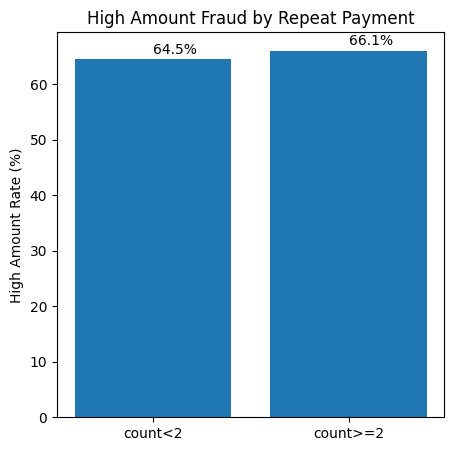

In [114]:
fraud = offline_df[offline_df['is_fraud'] == 1].copy()

# 연속결제 여부
fraud['repeat_payment'] = fraud['count_30min'] >= 2

# 고액 여부
fraud['high_amount'] = fraud['amt'] >= 150

summary = (
    fraud.groupby('repeat_payment')
    .agg(
        거래건수=('amt','count'),
        고액거래=('high_amount','sum')
    )
)

summary['고액비율(%)'] = (
    summary['고액거래']
    / summary['거래건수']
    *100
).round(2)

summary

import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))

plt.bar(
    ['count<2','count>=2'],
    summary['고액비율(%)']
)

for i,v in enumerate(summary['고액비율(%)']):
    plt.text(i,v+1,f'{v:.1f}%')

plt.ylabel("High Amount Rate (%)")
plt.title("High Amount Fraud by Repeat Payment")

plt.show()

In [115]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    fraud['repeat_payment'],
    fraud['high_amount']
)

chi2,p,dof,expected = chi2_contingency(table)

print("Chi-square :",chi2)
print("p-value :",p)

Chi-square : 0.9068363422866504
p-value : 0.34095522598980815


In [116]:
import statsmodels.formula.api as smf

fraud['repeat_payment'] = fraud['repeat_payment'].astype(int)
fraud['high_amount'] = fraud['high_amount'].astype(int)

model = smf.logit(
    'high_amount ~ repeat_payment',
    data=fraud
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.647682
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:            high_amount   No. Observations:                 4744
Model:                          Logit   Df Residuals:                     4742
Method:                           MLE   Df Model:                            1
Date:                Thu, 30 Jul 2026   Pseudo R-squ.:               0.0001590
Time:                        17:13:12   Log-Likelihood:                -3072.6
converged:                       True   LL-Null:                       -3073.1
Covariance Type:            nonrobust   LLR p-value:                    0.3228
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.5989      0.035     16.976      0.000       0.530       0.668
repeat_payment   

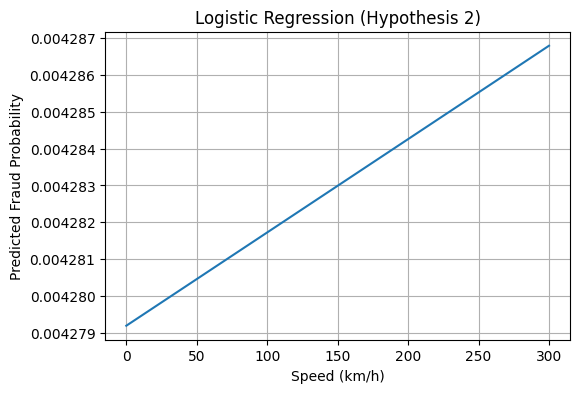

In [46]:
speed = np.linspace(0,300,100)

pred = model2.predict(
    sm.add_constant(pd.DataFrame({'speed_kmh': speed}), has_constant='add')
)

plt.figure(figsize=(6,4))

plt.plot(speed, pred)

plt.xlabel("Speed (km/h)")
plt.ylabel("Predicted Fraud Probability")
plt.title("Logistic Regression (Hypothesis 2)")

plt.grid(True)

plt.show()

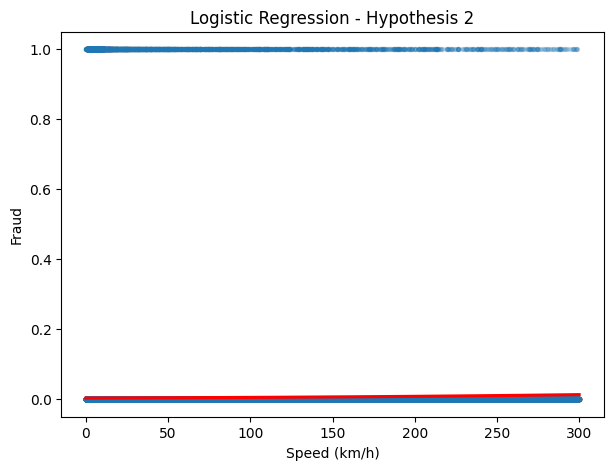

In [47]:
plot_df = speed_df[speed_df['speed_kmh'] <= 300]

plt.figure(figsize=(7,5))

sns.regplot(
    data=plot_df,
    x='speed_kmh',
    y='is_fraud',
    logistic=True,
    ci=None,
    scatter_kws={'alpha':0.15, 's':8},
    line_kws={'color':'red'}
)

plt.xlabel("Speed (km/h)")
plt.ylabel("Fraud")
plt.title("Logistic Regression - Hypothesis 2")

plt.show()

In [120]:
import pandas as pd
import matplotlib.pyplot as plt

# 사기거래만
fraud = df[df['is_fraud']==1].copy()

# 금액 구간
fraud['amt_group'] = pd.cut(
    fraud['amt'],
    bins=[0,20,50,100,200,500,1000],
    labels=[
        '0~20',
        '20~50',
        '50~100',
        '100~200',
        '200~500',
        '500+'
    ],
    include_lowest=True
)

# count_30min은 1~5만 사용
fraud = fraud[fraud['count_30min']<=5]

table = pd.crosstab(
    fraud['count_30min'],
    fraud['amt_group']
)

table

amt_group,0~20,20~50,50~100,100~200,200~500,500+
count_30min,,,,,,
1,973,275,25,95,1581,1781
2,208,67,12,44,382,672
3,57,13,6,7,75,194
4,9,3,2,4,17,45
5,0,2,0,0,1,7


<Figure size 1000x600 with 0 Axes>

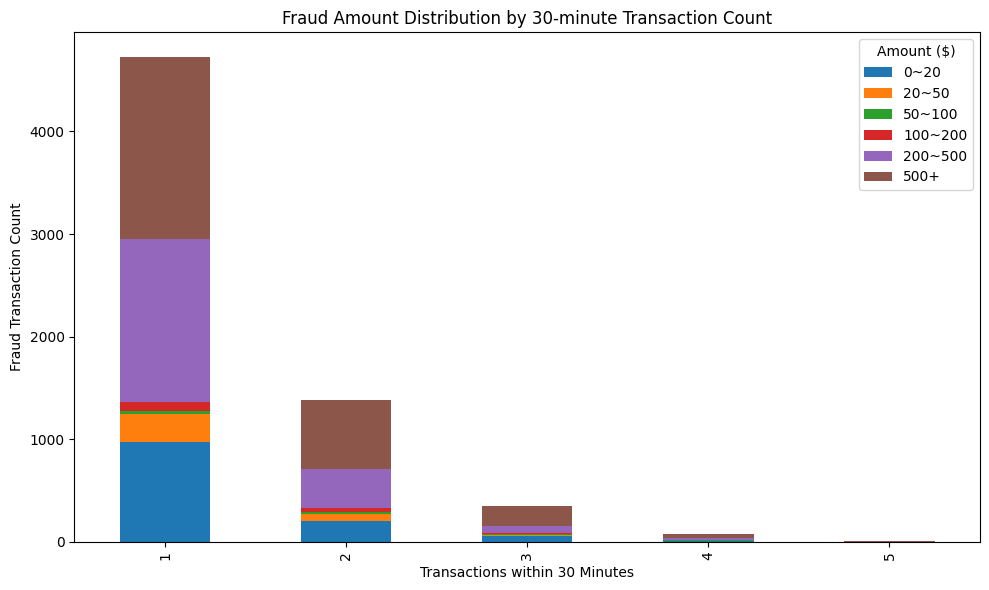

In [121]:
plt.figure(figsize=(10,6))

table.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.xlabel("Transactions within 30 Minutes")
plt.ylabel("Fraud Transaction Count")
plt.title("Fraud Amount Distribution by 30-minute Transaction Count")

plt.legend(title='Amount ($)')
plt.tight_layout()

plt.show()

In [122]:
import pandas as pd
import matplotlib.pyplot as plt

# 사기거래만
fraud = df[df['is_fraud']==1].copy()

# 금액 구간
fraud['amt_group'] = pd.cut(
    fraud['amt'],
    bins=[0,20,50,100,200,500,1000],
    labels=[
        '0~20',
        '20~50',
        '50~100',
        '100~200',
        '200~500',
        '500+'
    ],
    include_lowest=True
)

# count_30min은 1~5만 사용
fraud = fraud[fraud['count_30min']<=5]

table = pd.crosstab(
    fraud['count_30min'],
    fraud['amt_group']
)

table

amt_group,0~20,20~50,50~100,100~200,200~500,500+
count_30min,,,,,,
1,973,275,25,95,1581,1781
2,208,67,12,44,382,672
3,57,13,6,7,75,194
4,9,3,2,4,17,45
5,0,2,0,0,1,7


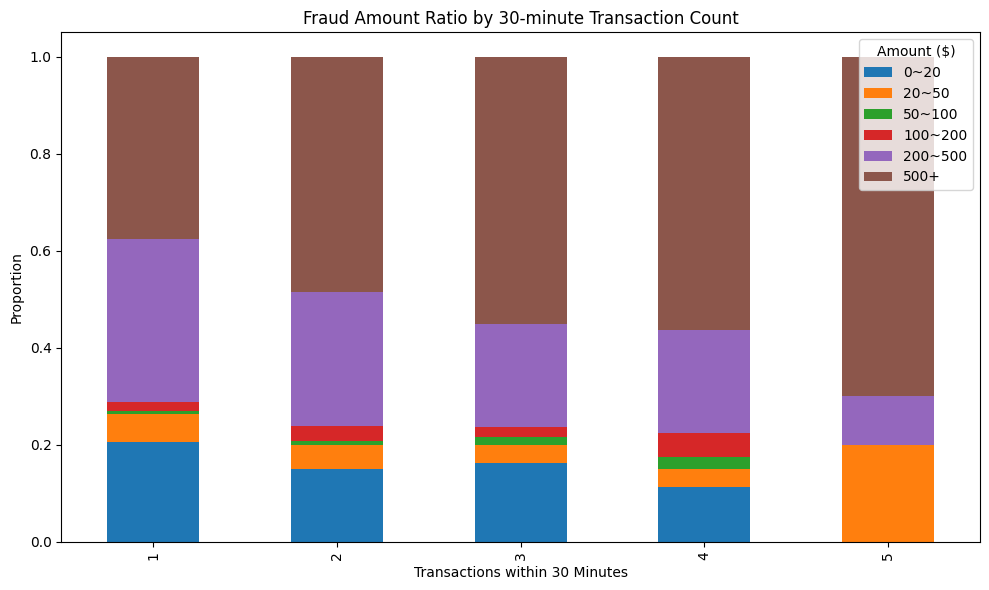

In [123]:
table_rate = table.div(table.sum(axis=1), axis=0)
table_rate.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.xlabel("Transactions within 30 Minutes")
plt.ylabel("Proportion")
plt.title("Fraud Amount Ratio by 30-minute Transaction Count")

plt.legend(title='Amount ($)')
plt.tight_layout()

plt.show()

In [124]:
import pandas as pd

df['amt_group'] = pd.cut(
    df['amt'],
    bins=[0,20,50,100,200,500,1000],
    labels=[
        '0~20',
        '20~50',
        '50~100',
        '100~200',
        '200~500',
        '500+'
    ],
    include_lowest=True
)

summary = (
    df.groupby('amt_group')
      .agg(
          거래건수=('is_fraud','count'),
          사기건수=('is_fraud','sum')
      )
)

summary['사기율(%)'] = (
    summary['사기건수']
    / summary['거래건수']
    *100
).round(3)

summary



/tmp/ipykernel_789/2987191094.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('amt_group')


,거래건수,사기건수,사기율(%)
amt_group,,,
0~20,424429,1247,0.294
20~50,247870,360,0.145
50~100,389483,45,0.012
100~200,172969,150,0.087
200~500,46293,2056,4.441
500+,11695,2699,23.078


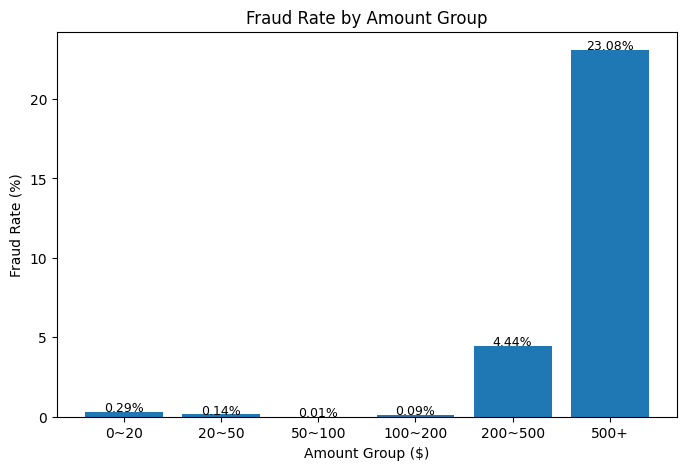

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    summary.index.astype(str),
    summary['사기율(%)']
)

for i, v in enumerate(summary['사기율(%)']):
    plt.text(i, v + 0.03, f'{v:.2f}%', ha='center', fontsize=9)

plt.xlabel("Amount Group ($)")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Amount Group")

plt.show()

In [126]:
from scipy.stats import chi2_contingency

# 200달러 이상 여부
df['high_amount'] = (df['amt'] >= 200).astype(int)

# 교차표
table = pd.crosstab(
    df['high_amount'],
    df['is_fraud']
)

print(table)

chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-square : {chi2:.3f}")
print(f"p-value : {p:.10f}")

is_fraud           0     1
high_amount               
0            1232943  1802
1              56226  5704
Chi-square : 84177.009
p-value : 0.0000000000


In [128]:
import numpy as np

df_test = offline_df.copy()

# 3회 이상 연속결제
df_test['repeat3'] = (df_test['count_30min'] >= 3).astype(int)

# 높은 이동속도 (80km/h 이상)
df_test['high_speed'] = (df_test['speed_kmh'] >= 80).astype(int)

In [129]:
summary = (
    df_test
    .groupby(['repeat3','high_speed'])
    .agg(
        거래건수=('is_fraud','count'),
        사기건수=('is_fraud','sum')
    )
)

summary['사기율(%)'] = (
    summary['사기건수']
    / summary['거래건수']
    *100
).round(2)

print(summary)

                      거래건수  사기건수  사기율(%)
repeat3 high_speed                      
0       0           900939  3129    0.35
        1           182391  1327    0.73
1       0              349    53   15.19
        1             6714   235    3.50


In [130]:
from scipy.stats import chi2_contingency

df_test['risk_group'] = (
    df_test['repeat3'].astype(str)
    + "_"
    + df_test['high_speed'].astype(str)
)

table = pd.crosstab(
    df_test['risk_group'],
    df_test['is_fraud']
)

chi2, p, dof, expected = chi2_contingency(table)

print(table)
print(f"\nChi-square = {chi2:.3f}")
print(f"p-value = {p:.10f}")

is_fraud         0     1
risk_group              
0_0         897810  3129
0_1         181064  1327
1_0            296    53
1_1           6479   235

Chi-square = 3729.646
p-value = 0.0000000000


In [131]:
import statsmodels.formula.api as smf

model = smf.logit(
    "is_fraud ~ repeat3 * high_speed",
    data=df_test
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.027389
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:               is_fraud   No. Observations:              1090393
Model:                          Logit   Df Residuals:                  1090389
Method:                           MLE   Df Model:                            3
Date:                Thu, 30 Jul 2026   Pseudo R-squ.:                 0.02175
Time:                        17:53:27   Log-Likelihood:                -29865.
converged:                       True   LL-Null:                       -30529.
Covariance Type:            nonrobust   LLR p-value:                1.306e-287
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -5.6592      0.018   -316.014      0.000      -5.694      -5.624
repe

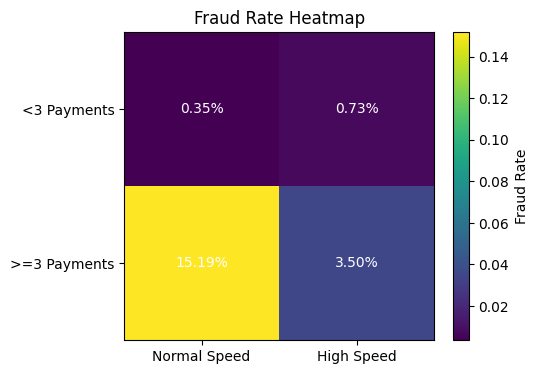

In [132]:
heat = (
    df_test.groupby(['repeat3','high_speed'])['is_fraud']
           .mean()
           .unstack()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

plt.imshow(heat, aspect='auto')

plt.xticks([0,1],['Normal Speed','High Speed'])
plt.yticks([0,1],['<3 Payments','>=3 Payments'])

plt.colorbar(label='Fraud Rate')

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            f"{heat.iloc[i,j]*100:.2f}%",
            ha='center',
            va='center',
            color='white'
        )

plt.title("Fraud Rate Heatmap")

plt.show()

In [ ]:
# 이동거리 구간 생성
bins = [0, 10, 30, 50, 100, 300, 500, 1000]

df['distance_group'] = pd.cut(
    df['move_distance_km'],
    bins=bins
)

distance_fraud = (
    df.groupby('distance_group', observed=False)
      .agg(
          transaction_count=('is_fraud','count'),
          fraud_count=('is_fraud','sum'),
          fraud_rate=('is_fraud','mean')
      )
      .reset_index()
)

distance_fraud


,distance_group,transaction_count,fraud_count,fraud_rate
0,"(0, 10]",10239,44,0.004297
1,"(10, 30]",72995,368,0.005041
2,"(30, 50]",126614,707,0.005584
3,"(50, 100]",430877,2615,0.006069
4,"(100, 300]",654967,3697,0.005645
5,"(300, 500]",0,0,NaN
6,"(500, 1000]",0,0,NaN


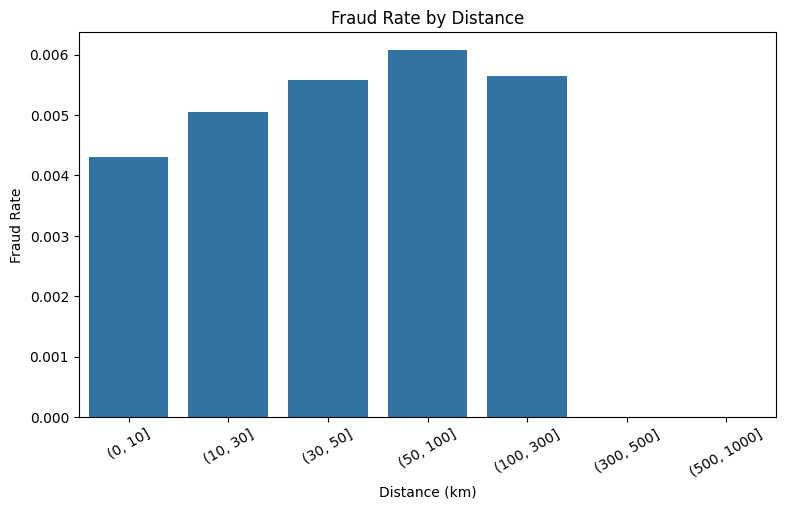

In [ ]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=distance_fraud,
    x='distance_group',
    y='fraud_rate'
)

plt.title("Fraud Rate by Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Fraud Rate")

plt.xticks(rotation=30)

plt.show()

In [30]:
bins = [0, 10, 30, 60, 100, 200, 500, 1000]

offline_df['speed_group'] = pd.cut(
    offline_df['speed_kmh'],
    bins=bins
)

speed_fraud = (
    offline_df.groupby('speed_group', observed=False)
      .agg(
          transaction_count=('is_fraud','count'),
          fraud_count=('is_fraud','sum'),
          fraud_rate=('is_fraud','mean')
      )
      .reset_index()
)

speed_fraud


,speed_group,transaction_count,fraud_count,fraud_rate
0,"(0, 10]",397873,1578,0.003966
1,"(10, 30]",303199,778,0.002566
2,"(30, 60]",150697,522,0.003464
3,"(60, 100]",80727,427,0.005289
4,"(100, 200]",72111,529,0.007336
5,"(200, 500]",49140,434,0.008832
6,"(500, 1000]",17384,196,0.011275


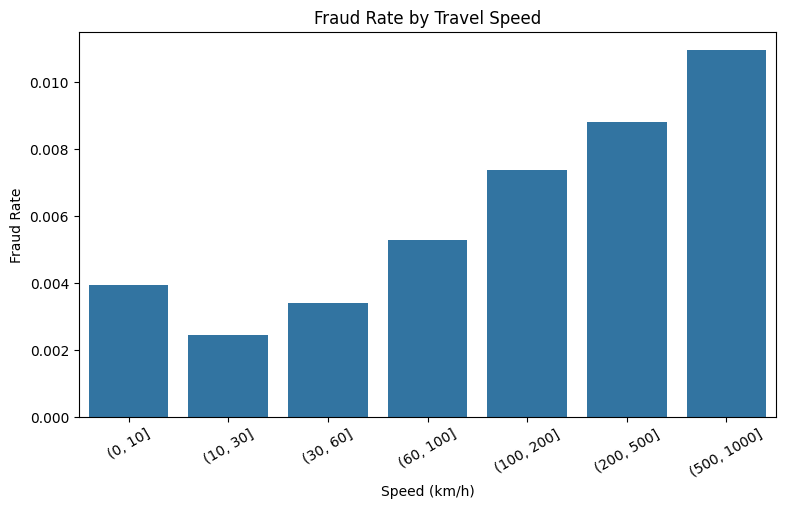

In [ ]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=speed_fraud,
    x='speed_group',
    y='fraud_rate'
)

plt.title("Fraud Rate by Travel Speed")
plt.xlabel("Speed (km/h)")
plt.ylabel("Fraud Rate")

plt.xticks(rotation=30)

plt.show()

In [28]:
offline_df['speed_kmh'] = offline_df['speed_kmh'].replace([np.inf, -np.inf], np.nan)

In [ ]:
df['speed_kmh'].describe()

,speed_kmh
count,1.295672e+06
mean,1.891645e+02
std,3.798020e+03
min,3.682387e-03
25%,7.599863e+00
50%,2.001696e+01
75%,5.876701e+01
max,7.806232e+05


In [32]:
speed_rate = (
    offline_df.groupby('speed_group', observed=False)
    .agg(
        transaction_count=('is_fraud','count'),
        fraud_count=('is_fraud','sum'),
        fraud_rate=('is_fraud','mean')
    )
    .reset_index()
)

speed_rate

,speed_group,transaction_count,fraud_count,fraud_rate
0,"(0, 10]",397873,1578,0.003966
1,"(10, 30]",303199,778,0.002566
2,"(30, 60]",150697,522,0.003464
3,"(60, 100]",80727,427,0.005289
4,"(100, 200]",72111,529,0.007336
5,"(200, 500]",49140,434,0.008832
6,"(500, 1000]",17384,196,0.011275


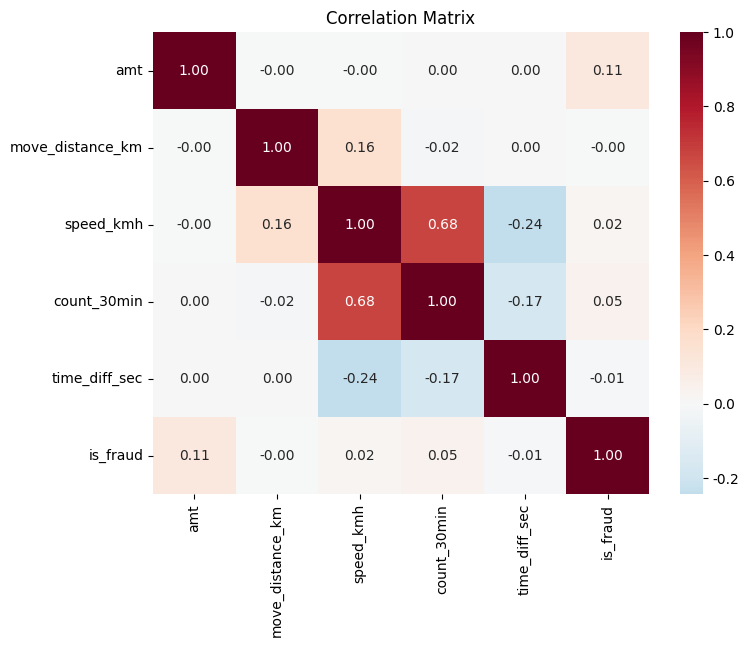

In [ ]:
corr_df = offline_df.copy()

# inf 제거
corr_df = corr_df.replace([np.inf, -np.inf], np.nan)

# 극단치 제거(99%)
corr_df = corr_df[
    corr_df['speed_kmh'] <= corr_df['speed_kmh'].quantile(0.99)
]

corr = corr_df[
    [
        'amt',
        'move_distance_km',
        'speed_kmh',
        'count_30min',
        'time_diff_sec',
        'is_fraud'
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

/tmp/ipykernel_507/3831674619.py:15: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  table=pd.pivot_table(


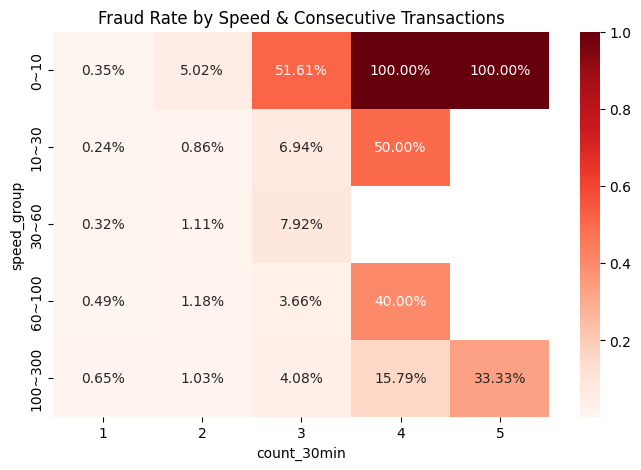

In [ ]:
pivot = offline_df.copy()

pivot = pivot.replace([np.inf,-np.inf],np.nan)

pivot = pivot[
    pivot['speed_kmh']<=300
]

pivot['speed_group']=pd.cut(
    pivot['speed_kmh'],
    bins=[0,10,30,60,100,300],
    labels=['0~10','10~30','30~60','60~100','100~300']
)

table=pd.pivot_table(
    pivot,
    values='is_fraud',
    index='speed_group',
    columns='count_30min',
    aggfunc='mean'
)

plt.figure(figsize=(8,5))

sns.heatmap(
    table,
    annot=True,
    cmap='Reds',
    fmt='.2%'
)

plt.title("Fraud Rate by Speed & Consecutive Transactions")

plt.show()

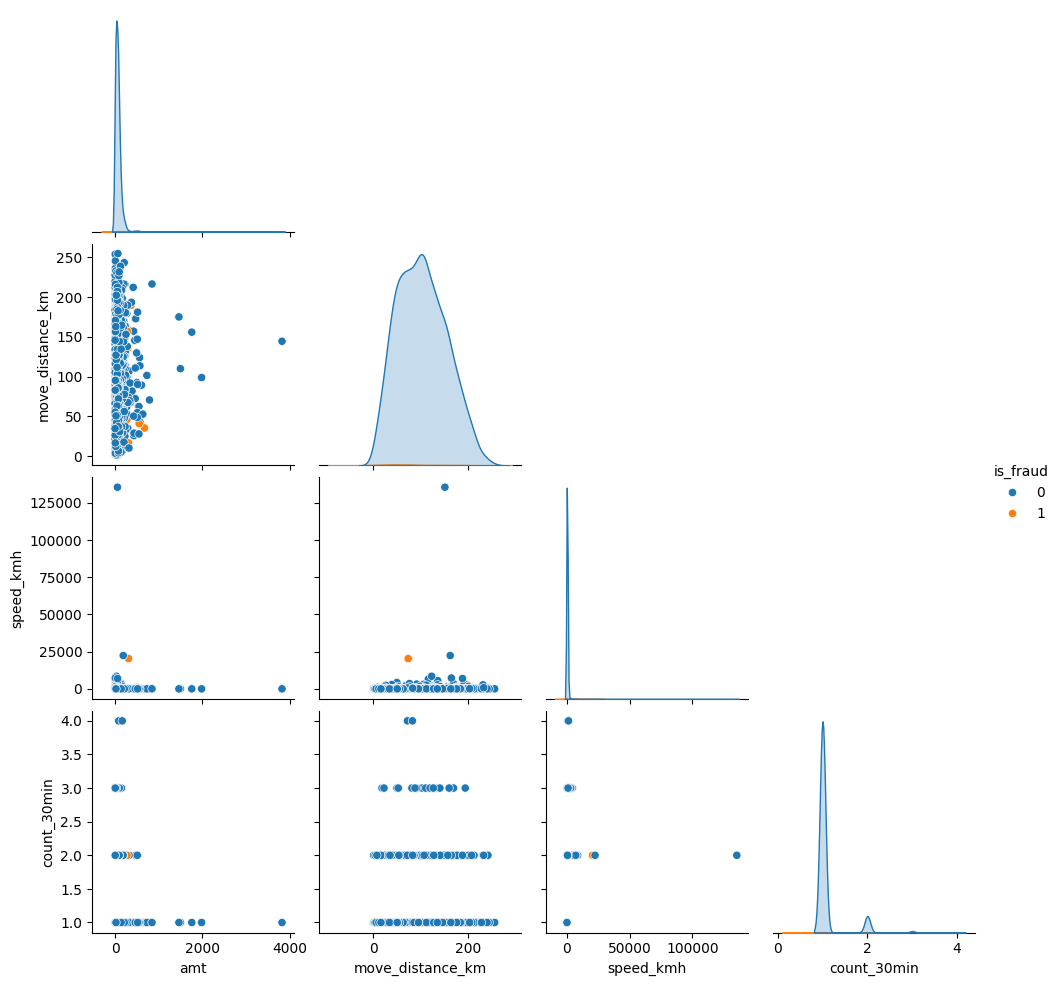

In [ ]:
pair_df = offline_df.sample(3000, random_state=42)

sns.pairplot(
    pair_df[
        [
            'amt',
            'move_distance_km',
            'speed_kmh',
            'count_30min',
            'is_fraud'
        ]
    ],
    hue='is_fraud',
    corner=True
)

plt.show()

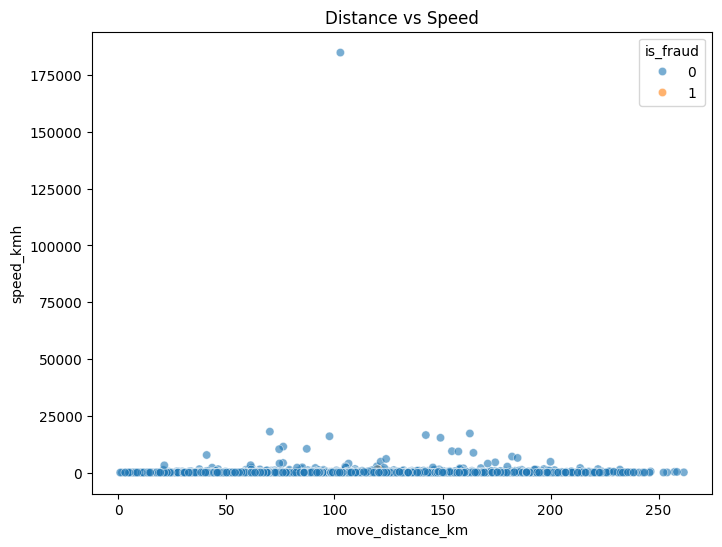

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=offline_df.sample(5000),
    x='move_distance_km',
    y='speed_kmh',
    hue='is_fraud',
    alpha=0.6
)

plt.title("Distance vs Speed")

plt.show()

/tmp/ipykernel_507/738993165.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(


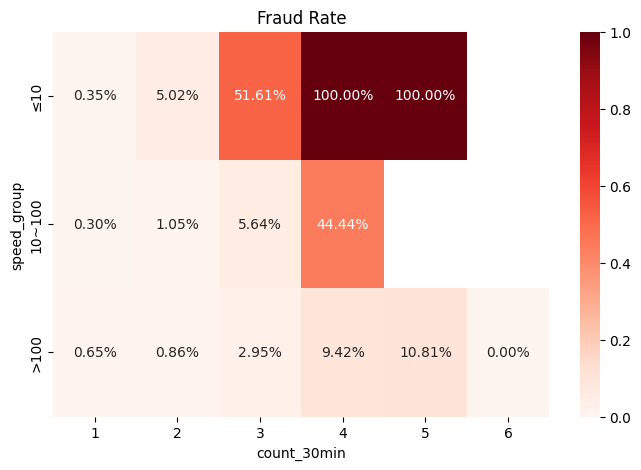

In [ ]:
offline_df['speed_group'] = pd.cut(
    offline_df['speed_kmh'],
    bins=[0,10,100,np.inf],
    labels=['≤10','10~100','>100']
)

pivot = pd.pivot_table(
    offline_df,
    values='is_fraud',
    index='speed_group',
    columns='count_30min',
    aggfunc='mean'
)

plt.figure(figsize=(8,5))

sns.heatmap(
    pivot,
    annot=True,
    cmap='Reds',
    fmt='.2%'
)

plt.title("Fraud Rate")
plt.show()

In [ ]:
speed_df = df.copy()

speed_df = speed_df.replace([np.inf, -np.inf], np.nan)

speed_df = speed_df.dropna(subset=['speed_kmh'])

speed_df = speed_df[speed_df['speed_kmh'] > 0]

In [27]:
###########수정 코드
df['speed_kmh'] = np.where(
    df['time_diff_sec'] > 0,
    df['move_distance_km'] / (df['time_diff_sec']/3600),
    np.nan
)

In [ ]:
df['speed_kmh'].describe()


,speed_kmh
count,1.295672e+06
mean,1.891645e+02
std,3.798020e+03
min,3.682387e-03
25%,7.599863e+00
50%,2.001696e+01
75%,5.876701e+01
max,7.806232e+05


In [ ]:

df[['time_diff_sec',
    'move_distance_km',
    'speed_kmh']].head(10)

,time_diff_sec,move_distance_km,speed_kmh
1017,NaN,NaN,NaN
2724,71862.0,224.769219,11.260043
2726,159.0,105.220439,2382.349553
2882,13838.0,88.152283,22.933099
2907,1952.0,132.876773,245.059622
4135,89149.0,112.505781,4.543190
4337,11315.0,71.815290,22.848877
5467,75285.0,85.440454,4.085616
6027,26247.0,60.852335,8.346417
6273,12302.0,146.839667,42.970476


In [26]:
df = df.sort_values(['cc_num','trans_date_trans_time'])

df['time_diff_sec'] = (
    df.groupby('cc_num')['trans_date_trans_time']
      .diff()
      .dt.total_seconds()
)

In [23]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):

    R = 6371

    lat1, lon1, lat2, lon2 = map(
        radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2-lat1
    dlon = lon2-lon1

    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2

    c = 2*atan2(sqrt(a), sqrt(1-a))

    return R*c

df['distance_km'] = df.apply(
    lambda x: haversine(
        x['lat'],
        x['long'],
        x['merch_lat'],
        x['merch_long']
    ),
    axis=1
)

In [24]:
df = df.sort_values(['cc_num', 'trans_date_trans_time'])

df['prev_lat'] = df.groupby('cc_num')['merch_lat'].shift(1)
df['prev_long'] = df.groupby('cc_num')['merch_long'].shift(1)

df['move_distance_km'] = df.apply(
    lambda x: haversine(
        x['prev_lat'],
        x['prev_long'],
        x['merch_lat'],
        x['merch_long']
    ) if pd.notnull(x['prev_lat']) else np.nan,
    axis=1
)

In [25]:
df['speed_kmh'] = (
    df['move_distance_km']
    /
    (df['time_diff_sec']/3600)
)